In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

%matplotlib inline

In [159]:
try: 
    df = pd.read_csv("ppr-group-25275889-train.csv", 
                     keep_default_na=True, 
                     delimiter=',', 
                     skipinitialspace=True)
    
    print(f"✓ Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
    
    display(df.head(3))

except FileNotFoundError:
    print("The file ppr-group-25275889-test.csv was not found in the current directory")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

✓ Successfully loaded dataset with 54000 rows and 9 columns


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,06/05/2016,"4 Millbourne Close, Slane Road, Ashbourne",Meath,NaN,"€249,969.16",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
1,09/12/2016,"26 Parkside Drive, Balgriffin, Dublin 13",Dublin,NaN,"€281,931.72",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
2,07/04/2016,"APT 2 FITZGERALD COURT, CALLAN, LOUTH",Louth,NaN,"€75,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [160]:
# DQR Function for PDF report
def build_dqr_table_report(df, columns, csv_filename):
    """
    Build and save a Data Quality Report table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
    columns : Index
        Features to include
    csv_filename : str
        Output filename
    
    Returns:
    --------
    pandas.DataFrame
        Complete DQR table
    """
    stats = df[columns].describe().T
    perc_missing = 100 * (df[columns].isnull().sum() / len(df))
    cardinality = df[columns].nunique()
    
    dqr_table = pd.concat([
        stats,
        pd.DataFrame(perc_missing, columns=['%missing']),
        pd.DataFrame(cardinality, columns=['cardinality'])
    ], axis=1)
    
    dqr_table.to_csv(csv_filename, index_label='Feature')
    return dqr_table


print("✓ Helper function loaded successfully")

✓ Helper function loaded successfully


In [161]:
# DQR Function for visualisations 
def build_dqr_table(df, columns):
    """
    Build and save a Data Quality Report table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
    columns : Index
        Features to include
    csv_filename : str
        Output filename
    
    Returns:
    --------
    pandas.DataFrame
        Complete DQR table
    """
    stats = df[columns].describe().T
    perc_missing = 100 * (df[columns].isnull().sum() / len(df))
    cardinality = df[columns].nunique()
    
    dqr_table = pd.concat([
        stats,
        pd.DataFrame(perc_missing, columns=['%missing']),
        pd.DataFrame(cardinality, columns=['cardinality'])
    ], axis=1)
    
    return dqr_table


print("✓ Helper function loaded successfully")

✓ Helper function loaded successfully


# Part 1: Data Quality Report


**Step 1: Standardisation and duplicate checks**

1. Create a copy of the Dataframe
2. Standardise column names
3. Strip away unnecessary syntax from "price" column
4. Transform feature types
5. Standardise address values before checking for duplicates
6. Check for duplicates 

In [162]:
# Make a copy of the dataframe 
df_copy = df.copy()

In [163]:
# Standardise column names 
df_copy.columns = df_copy.columns.str.lower().str.replace(r'\(dd/mm/yyyy\)', ' ', regex=True).str.replace("(€)", " ").str.strip().str.replace(" ", "_")

In [164]:
print("Column names are:")
for col in df_copy.columns:
    print(f"{col}")

Column names are:
date_of_sale
address
county
eircode
price
not_full_market_price
vat_exclusive
description_of_property
property_size_description


In [165]:
# Stripping away non-numeric from price cells
df_copy["price"] = (df_copy["price"]
                   .str.replace("€", "", regex=False)
                   .str.replace(",", "", regex=False)
                   .str.strip())

# Converting Price column from categorical to continuous
df_copy["price"] = df_copy["price"].astype("float64")

In [166]:
# Convert all object columns to categorical
for col in df_copy.select_dtypes('object').columns:
    df_copy[col] = df_copy[col].astype('category')

/var/folders/sf/cpst0jxn09170tcq8lkwcsjr0000gn/T/ipykernel_22242/667679956.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_copy.select_dtypes('object').columns:


In [167]:
# Update column groups after type corrections
numeric_columns = df_copy.select_dtypes(['int64', 'float64']).columns
category_columns = df_copy.select_dtypes('category').columns

print("✓ Data types corrected:")
print(f"  - Numeric features: {len(numeric_columns)}")
for col in numeric_columns:
    print(f"        {col}")
print()
print(f"  - Categorical features: {len(category_columns)}")
for col in category_columns:
    print(f"        {col}")

✓ Data types corrected:
  - Numeric features: 1
        price

  - Categorical features: 8
        date_of_sale
        address
        county
        eircode
        not_full_market_price
        vat_exclusive
        description_of_property
        property_size_description


In [168]:
# Standardise all values from all category columns to lowercase
for col in category_columns:
    df_copy[col] = df_copy[col].str.lower().str.strip()

In [169]:
# standardised address values 

to_replace = {r"\broad\b": "rd",
    r"\bstreet\b": "st",
    r"\bavenue\b": "ave",
    r"\bboulevard\b": "blvd",
    r"\bdrive\b": "dr",
    r"\bcourt\b": "ct",
    r"\blane\b": "la",
    r"\bpark\b": "prk",
    r"\bterrace\b": "ter",
    r"\bplace\b": "pl",
    r"\bsquare\b": "sq",
    r"\bapartment\b": "apt",
    r"\bapartments\b": "apts",
    r"\bco\b": "",
    r"\bcounty\b": "",
    r"\.": "",
    r",": ""
}

In [170]:
# Replacing them in address column
df_copy["address"] = df_copy["address"].replace(to_replace, regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
print("Standardisation of address values completed")

Standardisation of address values completed


In [171]:
print("Dataset Validation Checks:")
print("="*60)

# Dataset is not empty
if df_copy.empty:
    print("⚠ WARNING: Dataset is empty!")
else:
    print(f"✓ Dataset contains {df_copy.shape[0]:,} rows")

# Check for duplicate rows
duplicate_count = df_copy.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠ WARNING: Found {duplicate_count} duplicate rows")
else:
    print("✓ No duplicate rows found")

# Check if all columns are unnamed
unnamed_cols = [col for col in df_copy.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    print(f"⚠ WARNING: Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")
else:
    print("✓ All columns have names")

# Check for duplicates columns
dfT = df_copy.T
print(f"Number of duplicate columns is: {dfT.duplicated().sum()}")

Dataset Validation Checks:
✓ Dataset contains 54,000 rows
⚠ WARNING: Found 11 duplicate rows
✓ All columns have names
Number of duplicate columns is: 0


In [172]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date_of_sale               54000 non-null  object 
 1   address                    54000 non-null  object 
 2   county                     54000 non-null  object 
 3   eircode                    16908 non-null  object 
 4   price                      54000 non-null  float64
 5   not_full_market_price      54000 non-null  object 
 6   vat_exclusive              54000 non-null  object 
 7   description_of_property    54000 non-null  object 
 8   property_size_description  2872 non-null   object 
dtypes: float64(1), object(8)
memory usage: 3.7+ MB


**Duplicate checks** 

***Important information for Price (€)***

From the RPPR:

Apartments Nos 1 to 15 Oak Drive are sold for €2m:

- only one of the apartments (e.g. No. 1 Oak Drive) for a price of €2m;
- each apartment separately and divided the price between each apartment (e.g. Apartment No. 1 for €133,333, Apartment No.2 for €133,333 and so on to Apartment No. 15 for €133,333.
- all the apartments (e.g. Nos 1 to 15 Oak Drive) for a price of €2m.

In a small number of transactions included in the Register the price shown does not represent the full market price of the property concerned for a variety of reasons. For example, the price declared may reflect the retention of an interest in the property by the previous owner, or the fact that a part or fraction only of the property is being purchased; alternatively, the property may have been purchased at a reduced price under the Affordable Homes Scheme. In addition, in a very small number of cases, properties may be declared as purchased in exchange for other property, stocks and shares, etc. All such properties are marked ** (Not Full Market Price in the dataset)

In [173]:
# Identifying duplicates, where all columns in rows match
true_duplicate_rows = df_copy[df_copy.duplicated()]

In [174]:
# Dropping "true" duplicates
df_copy = df_copy.drop_duplicates(true_duplicate_rows)
print("Dropped duplicates from the Dataframe")

Dropped duplicates from the Dataframe


**Step 2: Summary statistics for numeric & categorical features**
1. Numeric features
2. Categorical features

In [175]:
print("Numeric columns:")
for col in numeric_columns:
    print(f"{col}")

Numeric columns:
price


In [176]:
pd.set_option("display.precision", 2)
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
price,53989.0,323991.7,1.13e+06,5180.0,157500.0,250000.0,365000.0,1.39e+08


In [177]:
# Summary statistics for numeric features
numeric_dqr_table = build_dqr_table_report(df_copy, numeric_columns, "Data_Quality_Report_Summary_Numeric.csv")
print("Summary table for Numeric features saved successfully")
display(numeric_dqr_table)

Summary table for Numeric features saved successfully


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,53989.0,323991.7,1.13e+06,5180.0,157500.0,250000.0,365000.0,1.39e+08,0.0,6784


In [178]:
print("Category columns:")
for col in category_columns:
    print(f"{col}")

Category columns:
date_of_sale
address
county
eircode
not_full_market_price
vat_exclusive
description_of_property
property_size_description


In [179]:
# Summary statistics for categorical features
category_dqr_table = build_dqr_table_report(df_copy, category_columns, "Data_Quality_Report_Summary_Categorical.csv")
print("Summary table for Categorical features saved successfully")
display(category_dqr_table)
print("="*60)

Summary table for Categorical features saved successfully


,count,unique,top,freq,%missing,cardinality
date_of_sale,53989,2503,18/12/2020,105,0.00,2503
address,53989,53081,main st dunmanway cork,4,0.00,53081
county,53989,26,dublin,16677,0.00,26
eircode,16903,16853,d24w9nn,3,68.69,16853
not_full_market_price,53989,2,no,51122,0.00,2
vat_exclusive,53989,2,no,44441,0.00,2
description_of_property,53989,3,second-hand dwelling house /apartment,44281,0.00,3
property_size_description,2872,4,greater than or equal to 38 sq metres and less...,2174,94.68,4


From both tables, we can analyse that:
- **Price** feature has no missing values but a very large maximum value. Analysis of outliers needs to be performed.
- **Date of sale** feature has no missing value, but has a high frequency. Its usefulness as a current feature is limited. The creation of new features (month, quarter, year) could be more appropriate for our objective. 
- **Address** feature has a very high frequency. This suggest creating new features for better predictive value. 
- **County** feature does not have a high frequency, and can be kept as is for now.
- **Eircode** feature has a high percentage of missing values. However, it could be the best feature for "location". Investigation into recovering Eircode values must be done.
- **Not full market price** feature has no missing values. It is a boolean feature with a high percentage of "no". It describes whether a property's sale price respresents the true market value of said property. The RPPR is vague and imprecise on the possible nature of this mis-representation. At this stage, it seems that rows with a value "yes" may create noise in the data.
- **VAT exclusive** feature has no missing percentage. It is a boolean feature that represents whether VAT must be added to the sale price. Investigation is required to understand if there are any properties that do not need to be updated based on vat.
- **Description of property** feature has no missing values. It has 3 unique values. This could be related to VAT Exclusive feature, since only new builds are subject to vat in Ireland. Investigation into the need to keep this feature  and VAT Exclusive is required. 
- **Property size description** feature has a very high percentage of missing values. Investigation how to recover data, otherwise drop.

**Step 3: Investigating some features in more depth before plotting.** 
1. Not full market price
2. vat exclusive

**Not full market price** 

In [180]:
# Creating a new dataframe with only builds that are not full market price
nfmp_yes = df_copy[df_copy["not_full_market_price"] == "yes"]

In [181]:
# Building a summary table to analyse the price feature based on this condition
nfmp_yes_num = nfmp_yes.select_dtypes(['int64', 'float64']).columns
print("Summary table of the Price feature for rows with 'not_full_market_price' == 'yes' ")
nfmp_yes_dqr = build_dqr_table(nfmp_yes, nfmp_yes_num)
display(nfmp_yes_dqr)

Summary table of the Price feature for rows with 'not_full_market_price' == 'yes' 


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,2867.0,298617.53,3.08e+06,5180.0,91420.0,168304.11,250122.37,1.39e+08,0.0,1101


In [182]:
# Creating a new dataframe with builds that are full market price
nfmp_no = df_copy[df_copy["not_full_market_price"] == "no"]

In [183]:
# Building a summary table to analyse the price feature based on this condition
nfmp_no_num = nfmp_no.select_dtypes(['int64', 'float64']).columns
print("Summary table of the Price feature for rows with 'not_full_market_price' == 'no' ")
nfmp_no_dqr = build_dqr_table(nfmp_no, nfmp_no_num)
display(nfmp_no_dqr)

Summary table of the Price feature for rows with 'not_full_market_price' == 'no' 


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,51122.0,325414.72,904073.33,5250.0,162000.0,256000.0,370044.05,1.36e+08,0.0,6139


**Initial findings**

"Not Full Market Price" is a flag that represents any transactions that are not representative of the "True" market value of a property. This can be for a myriad of reasons, with no clear guidelines or rules on the nature of these transactions. From the Summary tables above, the data for "yes" is statistically lower than that of "no". 


More generally, it seems that this could be incomplete data. Not having any more insights into the nature of these transactions, or whether our dataset has all sub-transactions of a transaction of property, I would advise to flag this data in the Data Quality Plan. Essentially, incomplete data can skew the overall data more than the potential gains we could have from fixing it, without having any evidence that potential fixes - such as aggregating, keeping highest value, etc... - are the correct undertaking.

**VAT Exclusive**

In [184]:
# Creating a new dataframe with rows that don't have VAT 
vat_yes = df_copy[df_copy["vat_exclusive"] == "yes"]

In [185]:
# Building summary table to analyse the price feature based on this condition
vat_yes_num = vat_yes.select_dtypes(['int64', 'float64']).columns
print("Summary table of the Price feature for rows with 'vat_exclusive' == 'yes' ")
vat_yes_dqr = build_dqr_table(vat_yes, vat_yes_num)
display(vat_yes_dqr)

Summary table of the Price feature for rows with 'vat_exclusive' == 'yes' 


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,9548.0,421799.8,1.88e+06,8333.0,242290.74,308370.05,396475.83,1.36e+08,0.0,3711


In [186]:
# Investigating whether some entries are second hand build and don't have VAT 
mask = (df_copy["vat_exclusive"] == "yes") & (df_copy["description_of_property"] != "new dwelling house /apartment")
vat_yes_new = df_copy[mask]

if len(vat_yes_new) == 0:
    print("There are no Second-hand builds that require VAT, which is a good sign !")
else:
    print("Some rows need looking into")

There are no Second-hand builds that require VAT, which is a good sign !


In [187]:
# Looking at price data when new properties have been adjusted to reflect gross price
df_vat = df_copy.copy()
df_vat.loc[df_vat["vat_exclusive"] == "yes", "price"] = df_vat["price"] * 1.135

In [188]:
# This can be compared to the original summary
print("Comparing Summary table for Price before and after adjusting for VAT\n")

print("Before adjusting for VAT:")
before_vat_dqr = build_dqr_table(df_copy, numeric_columns)
display(before_vat_dqr)


print("\nAfter adjusting for VAT")
vat_num = df_vat.select_dtypes(['int64', 'float64']).columns
df_vat_dqr = build_dqr_table(df_vat, vat_num)
display(df_vat_dqr)

Comparing Summary table for Price before and after adjusting for VAT

Before adjusting for VAT:


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,53989.0,323991.7,1.13e+06,5180.0,157500.0,250000.0,365000.0,1.39e+08,0.0,6784



After adjusting for VAT


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
price,53989.0,334062.11,1.21e+06,5180.0,160000.0,259000.0,380000.0,1.54e+08,0.0,7238


**Initial findings**

Firstly, no rows have VAT Exclusive == Yes and that aren't new builds. This helps us identify there aren't any errors in the data entry of second hand houses having not added on VAT (good because second-hand houses do not pay VAT). 

Almost 10K entries do not have VAT, so adjusting this in the Data Cleaning Phase is necesssary. Once that is complete, I would suggest to drop this feature, since it is a flag.

**Step 4: Visualisations for continuous & categorical features**

In [189]:
print("Numeric Column:")
print("price")

Numeric Column:
price


In [190]:
price = df_copy.iloc[:, 4]

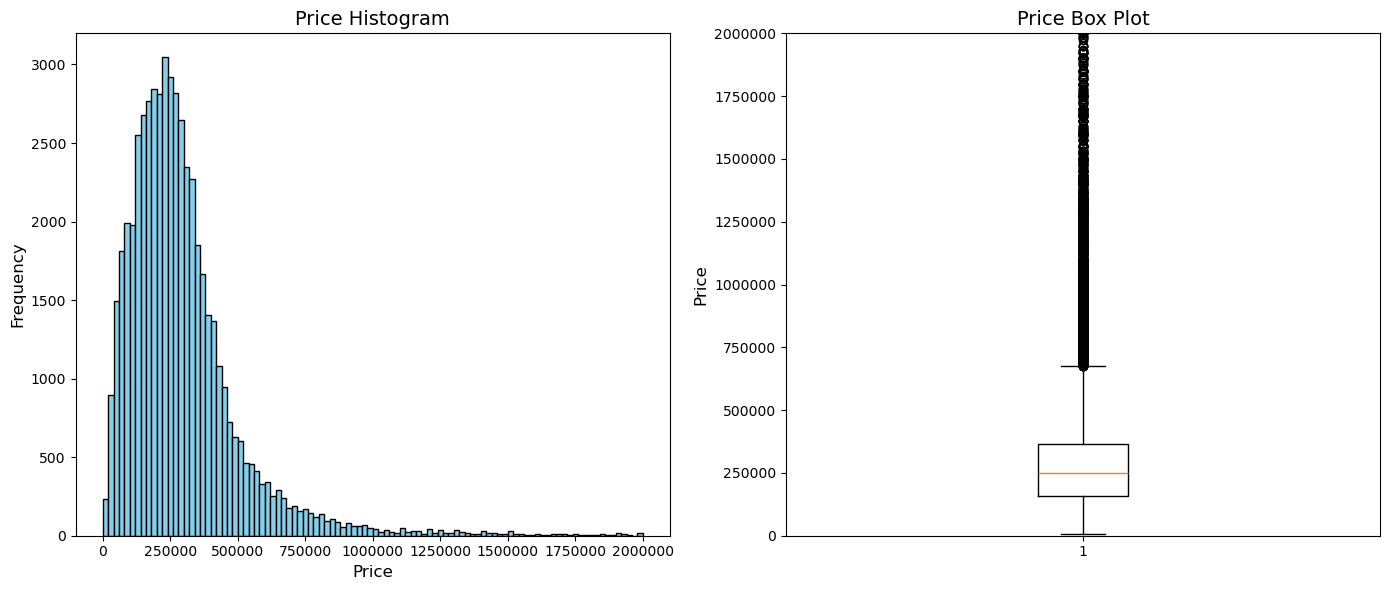

In [191]:
# Plotting the histogram and Box Plot for the Price feature

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Capping the maximum value at 2 Million for readability
axes[0].hist(price, bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[0].set_xlabel('Price', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Price Histogram', fontsize=14)
axes[0].ticklabel_format(style='plain', axis='x')

# Capping the maximum value at 2 Million for readability
axes[1].boxplot(price)
axes[1].set_ylim(0, 2_000_000)
axes[1].set_title('Price Box Plot', fontsize=14)
axes[1].set_ylabel('Price', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='y')


plt.tight_layout()
plt.show()

**Plotting Price feature for Dataframes that have:**
- Only Not Full Market Price builds
- Only Full Market Price builds
- Adjusting for VAT

The visual comparison between the first two Dataframes emphasizes the statistical differences between properties who are at full market price, and those that aren't

Comparing the third Dataframe with the original Price feature to look at visual differences

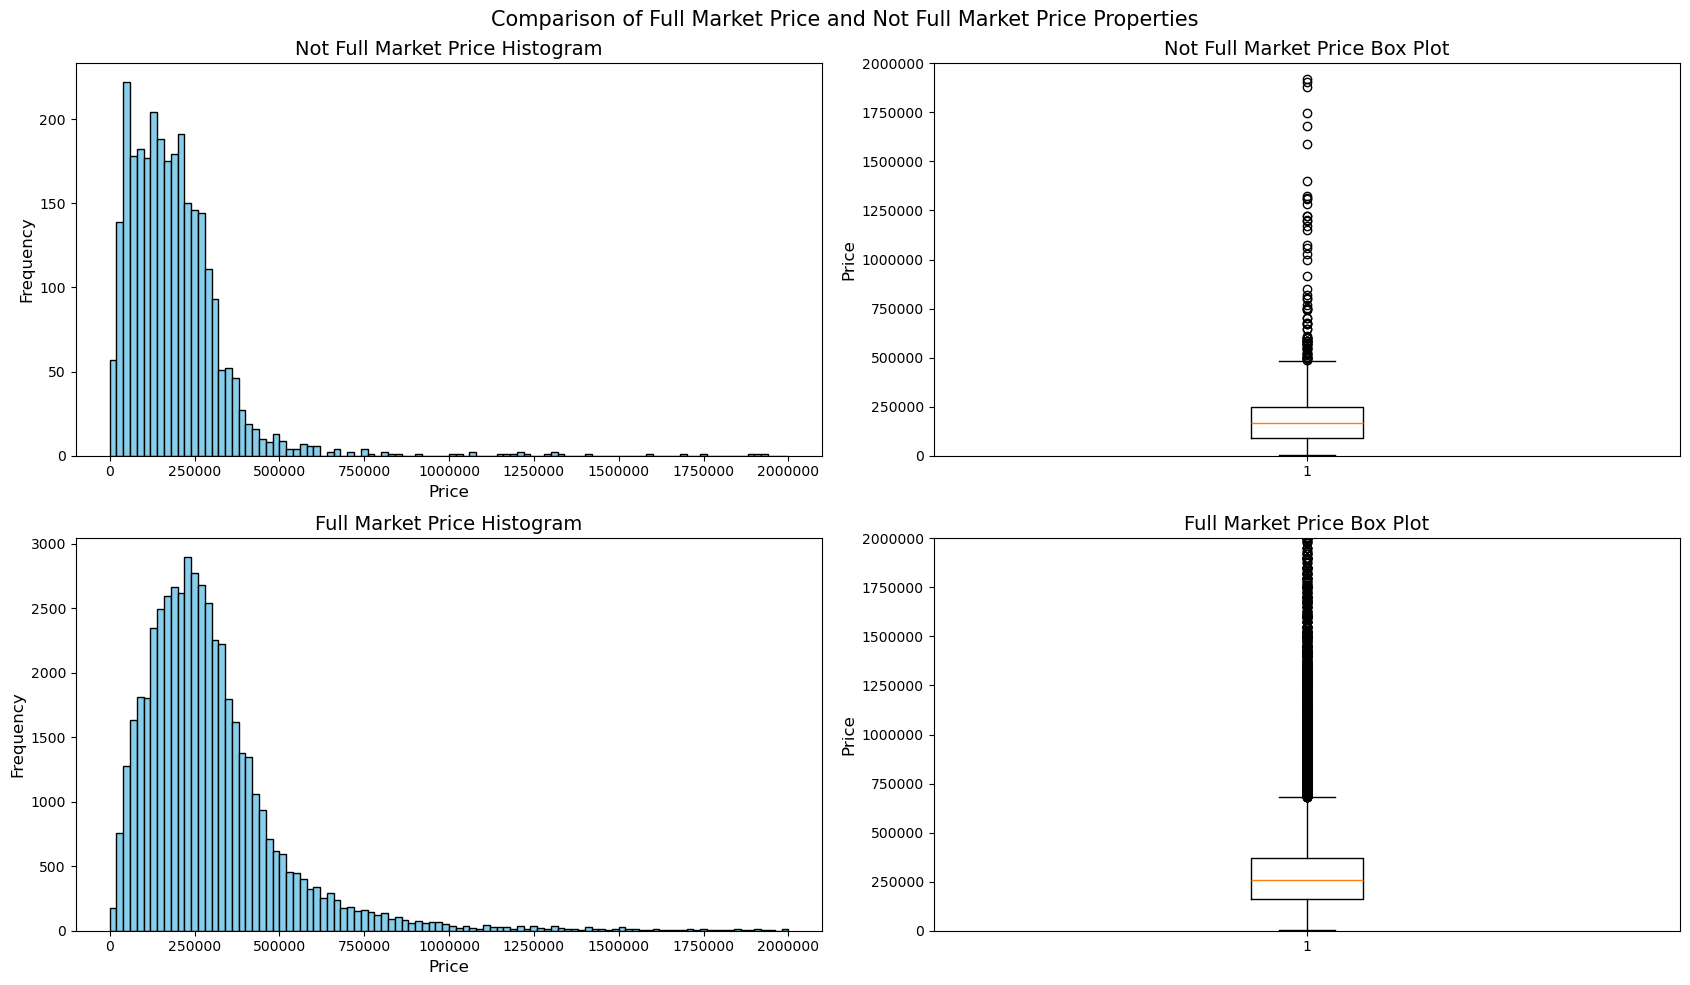

In [192]:
# Plotting both Full Market Price and Not Full Market Price properties

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Comparison of Full Market Price and Not Full Market Price Properties", fontsize=15)


# Not full market price 
plot_nfmp_yes = nfmp_yes.iloc[:, 4]

# Histogram
axes[0, 0].hist(plot_nfmp_yes, bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[0, 0].set_xlabel('Price', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Not Full Market Price Histogram', fontsize=14)
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[0, 1].boxplot(plot_nfmp_yes)
axes[0, 1].set_ylim(0, 2_000_000)
axes[0, 1].set_title('Not Full Market Price Box Plot', fontsize=14)
axes[0, 1].set_ylabel('Price', fontsize=12)
axes[0, 1].ticklabel_format(style='plain', axis='y')

###################################################

# Full market price
plot_nfmp_no = nfmp_no.iloc[:, 4]

# Histogram
axes[1, 0].hist(plot_nfmp_no, bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[1, 0].set_xlabel('Price', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Full Market Price Histogram', fontsize=14)
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[1, 1].boxplot(plot_nfmp_no)
axes[1, 1].set_ylim(0, 2_000_000)
axes[1, 1].set_title('Full Market Price Box Plot', fontsize=14)
axes[1, 1].set_ylabel('Price', fontsize=12)
axes[1, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

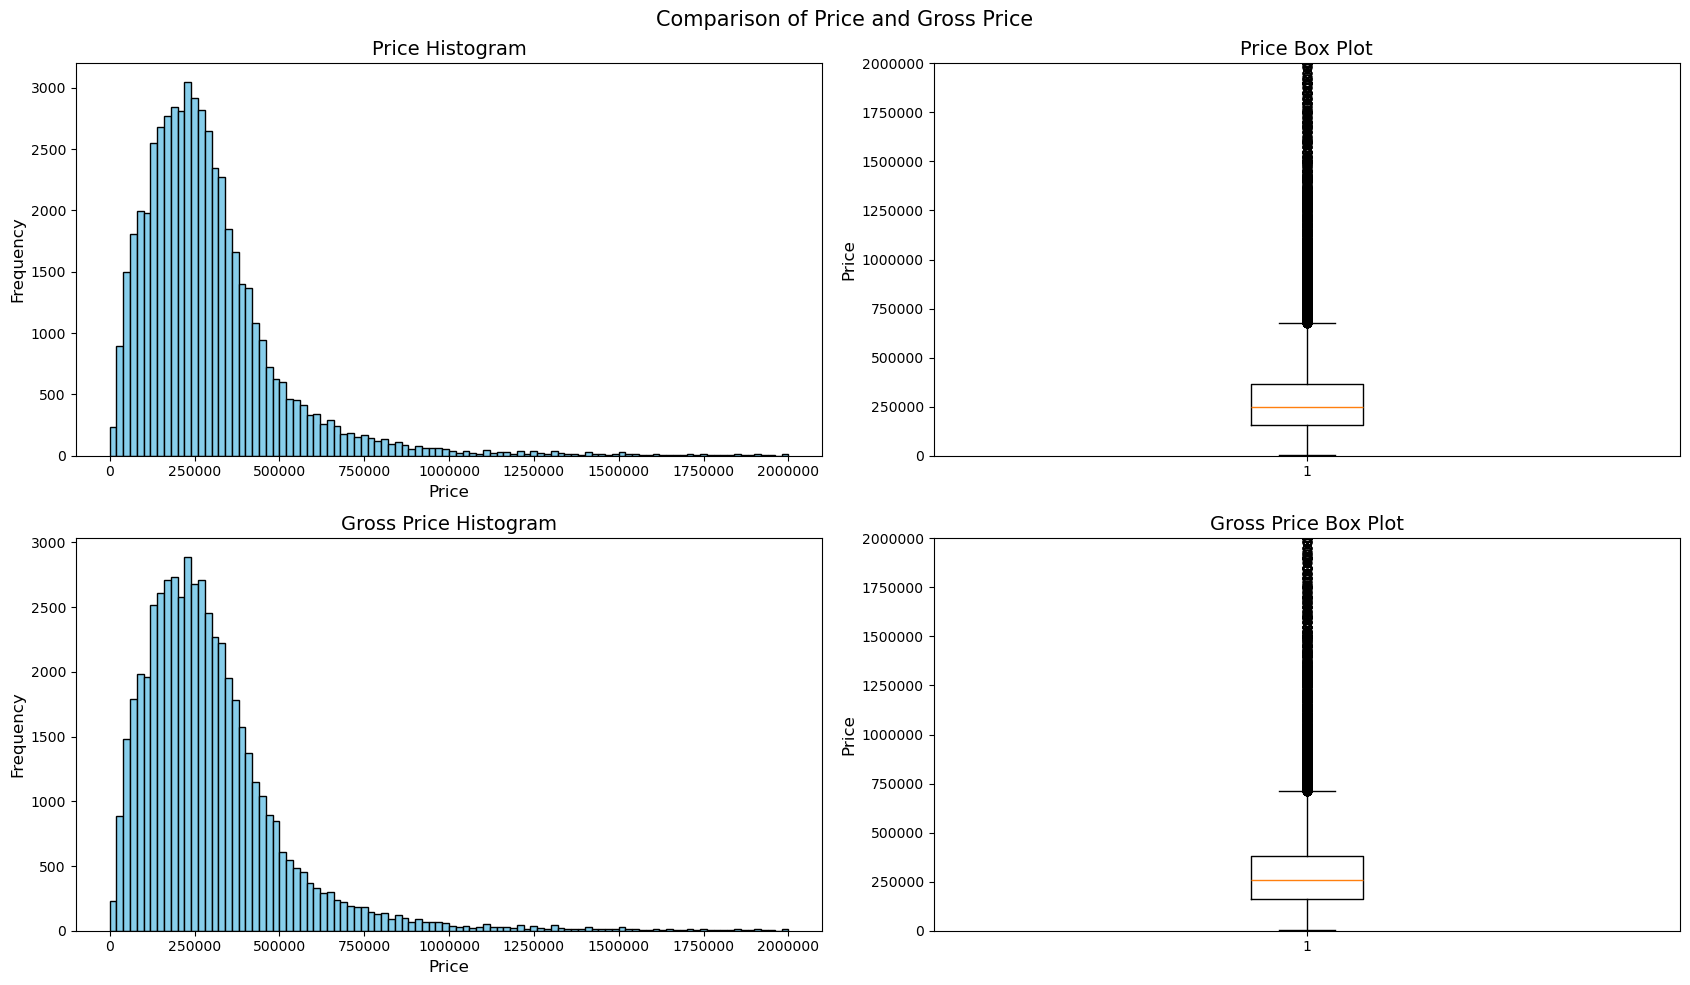

In [193]:
# Plotting both Price and Gross Price

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Comparison of Price and Gross Price", fontsize=15)


# Histogram
axes[0, 0].hist(price, bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[0, 0].set_xlabel('Price', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Price Histogram', fontsize=14)
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[0, 1].boxplot(price)
axes[0, 1].set_ylim(0, 2_000_000)
axes[0, 1].set_title('Price Box Plot', fontsize=14)
axes[0, 1].set_ylabel('Price', fontsize=12)
axes[0, 1].ticklabel_format(style='plain', axis='y')

###################################################

# Gross price
gross_price = df_vat.iloc[:, 4]

# Histogram
axes[1, 0].hist(gross_price, bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[1, 0].set_xlabel('Price', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Gross Price Histogram', fontsize=14)
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[1, 1].boxplot(gross_price)
axes[1, 1].set_ylim(0, 2_000_000)
axes[1, 1].set_title('Gross Price Box Plot', fontsize=14)
axes[1, 1].set_ylabel('Price', fontsize=12)
axes[1, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

In [194]:
print("Category columns:")
for col in category_columns:
    print(f"{col}")

Category columns:
date_of_sale
address
county
eircode
not_full_market_price
vat_exclusive
description_of_property
property_size_description


**Visualisations for categorical features**

Changing date_of_sale feature to better visualise the distribution per year, quarter, month and year-month

In [195]:
# Changing dates to visualise them 

df_copy["date_of_sale"] = pd.to_datetime(df_copy["date_of_sale"], format="%d/%m/%Y")

In [196]:
# Creating new columns in copied dataframe to visualise per year/month/quarter/year-month

year = df_copy['date_of_sale'].dt.year
month = df_copy['date_of_sale'].dt.month
quarter = df_copy['date_of_sale'].dt.quarter
year_month = df_copy['date_of_sale'].dt.to_period('M')

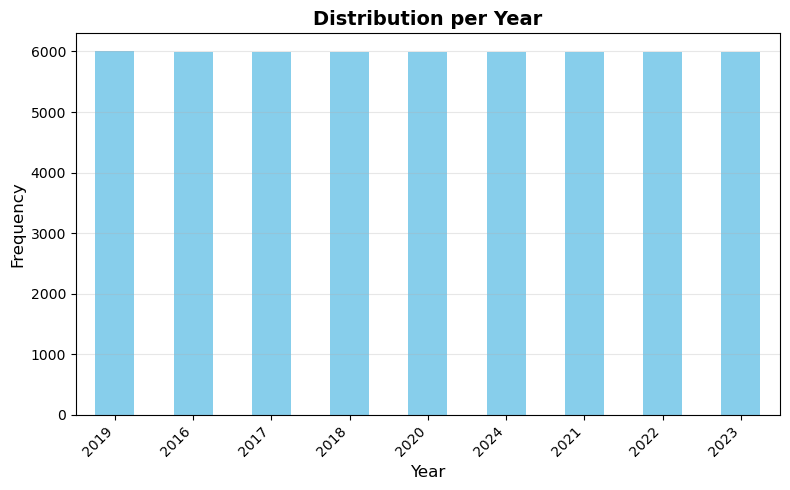

In [197]:
# Distribution per year

plt.figure(figsize=(8, 5))
year.value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

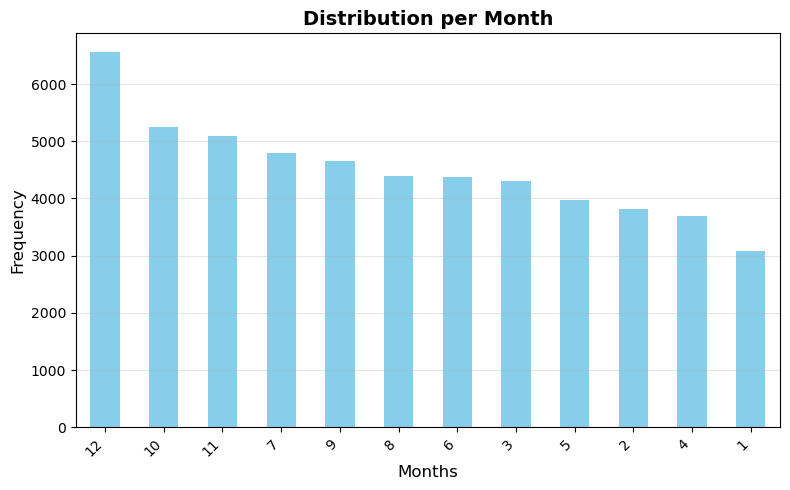

In [198]:
# Distribution per month

plt.figure(figsize=(8, 5))
month.value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution per Month', fontsize=14, fontweight='bold')
plt.xlabel('Months', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

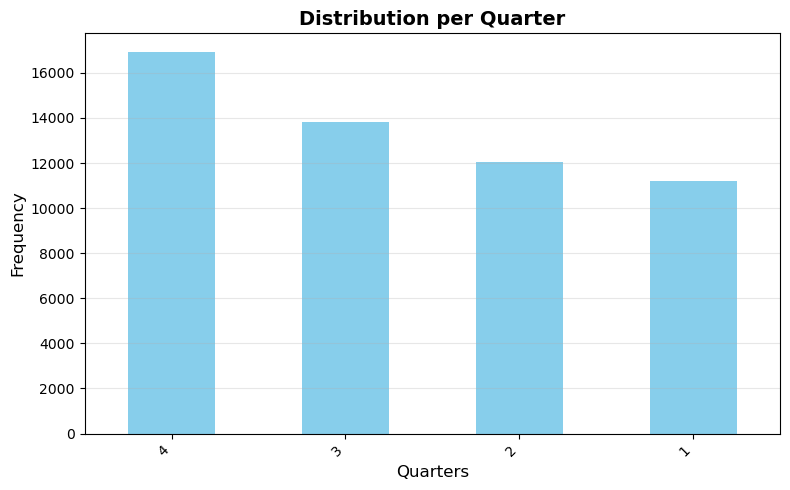

In [199]:
# Distibution per quarter

plt.figure(figsize=(8, 5))
quarter.value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution per Quarter', fontsize=14, fontweight='bold')
plt.xlabel('Quarters', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

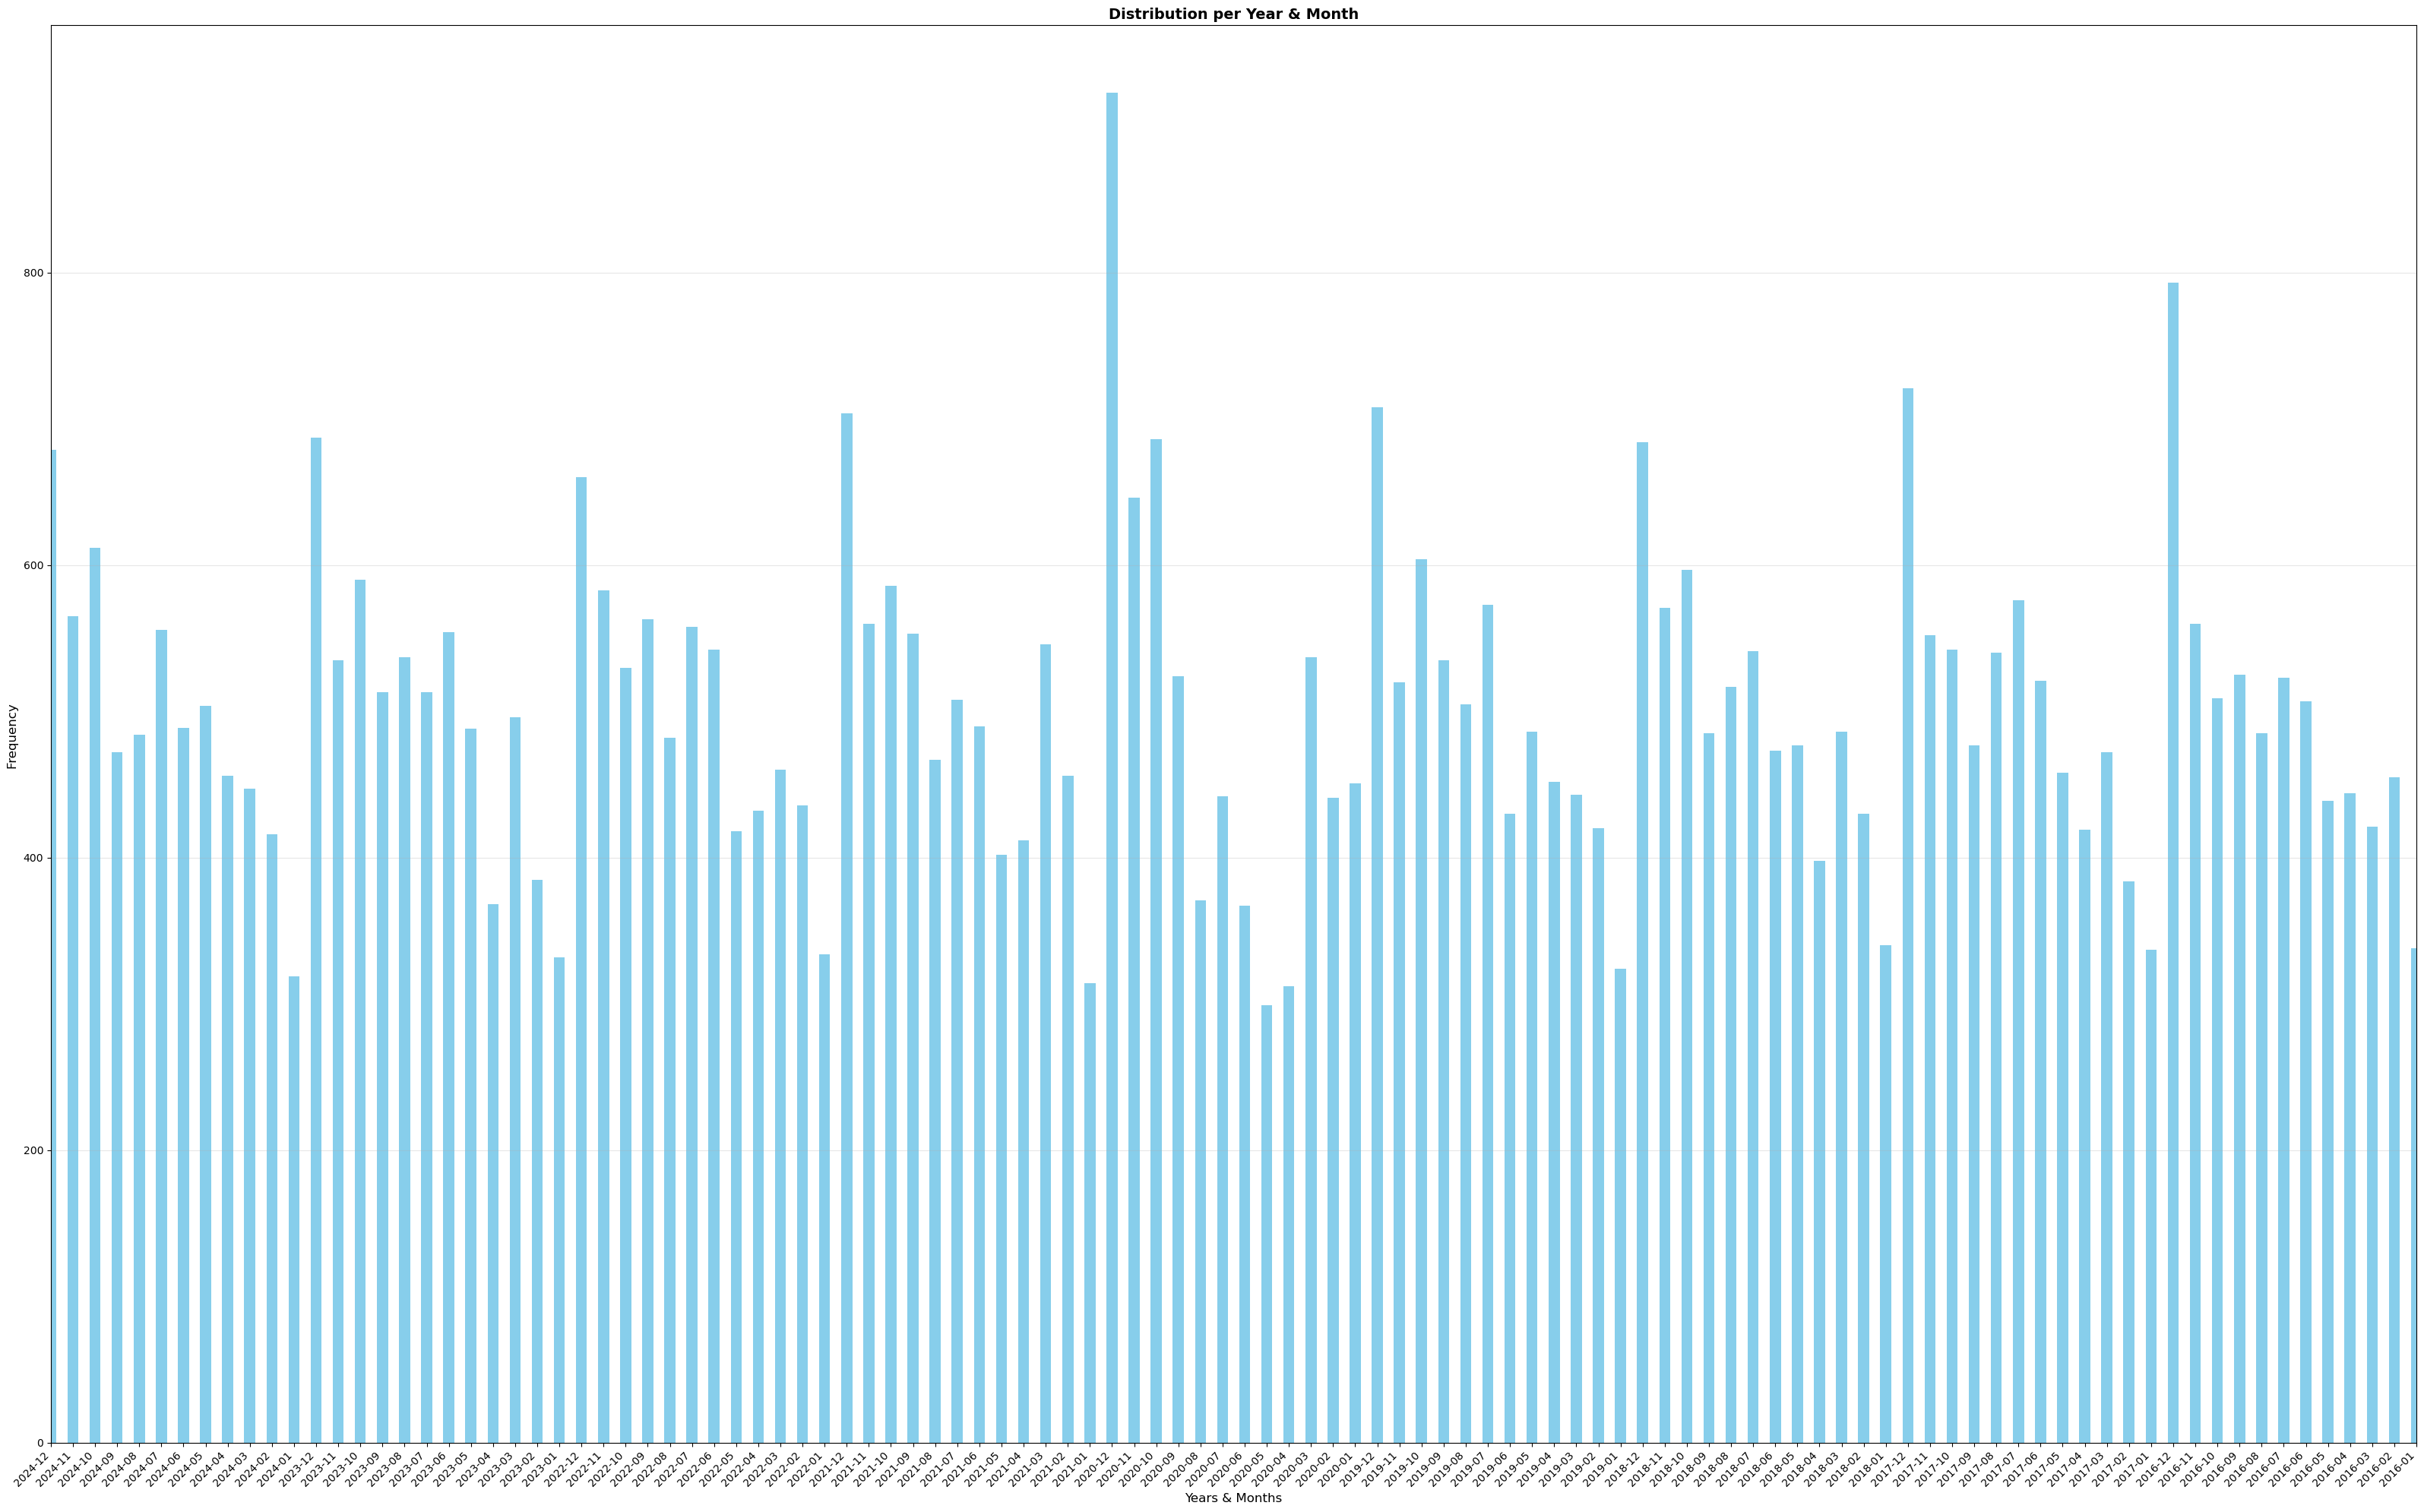

In [200]:
# Distribution per month-year

plt.figure(figsize=(32, 20))
year_month.value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution per Year & Month', fontsize=14, fontweight='bold')
plt.xlabel('Years & Months', fontsize=12)
plt.ylabel('Frequency ', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Plotting the remaining categorical features to have a first look at the distibution**

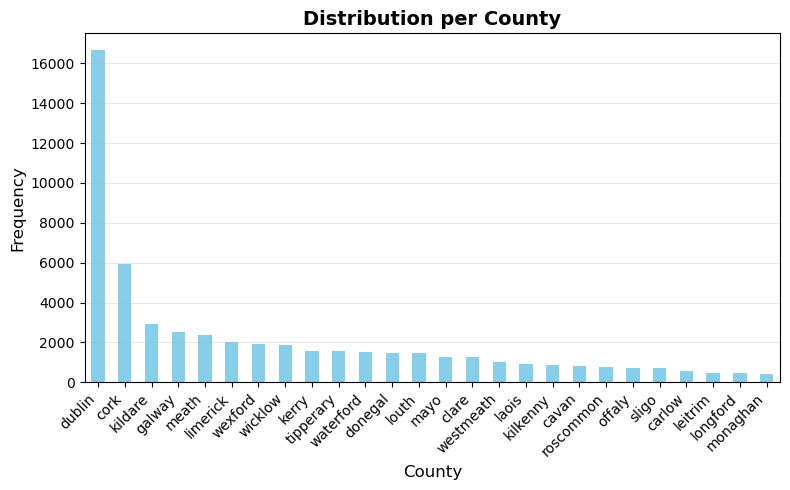

In [201]:
# County feature

plt.figure(figsize=(8, 5))
df_copy['county'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution per County', fontsize=14, fontweight='bold')
plt.xlabel('County', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

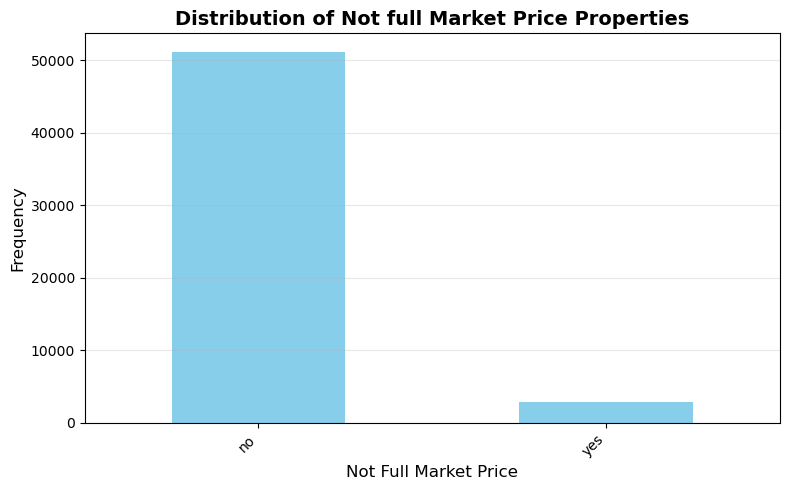

In [202]:
# Not Full Market Price feature 

plt.figure(figsize=(8, 5))
df_copy['not_full_market_price'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution of Not full Market Price Properties', fontsize=14, fontweight='bold')
plt.xlabel('Not Full Market Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

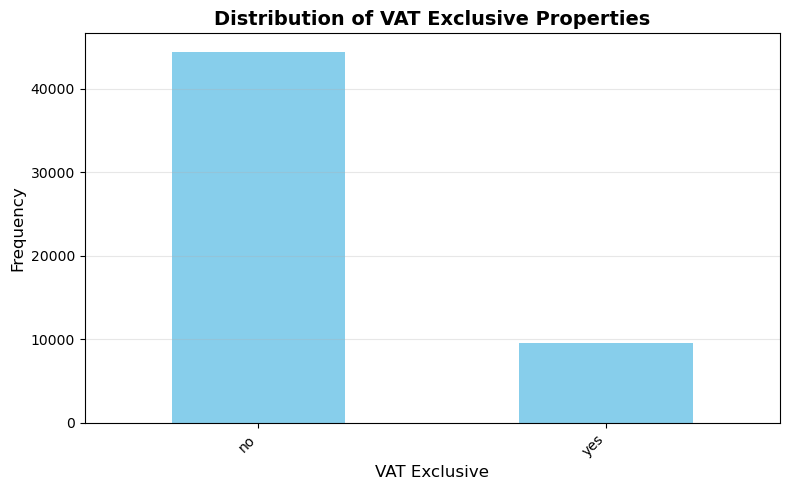

In [203]:
# VAT Exclusive

plt.figure(figsize=(8, 5))
df_copy['vat_exclusive'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution of VAT Exclusive Properties', fontsize=14, fontweight='bold')
plt.xlabel('VAT Exclusive', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

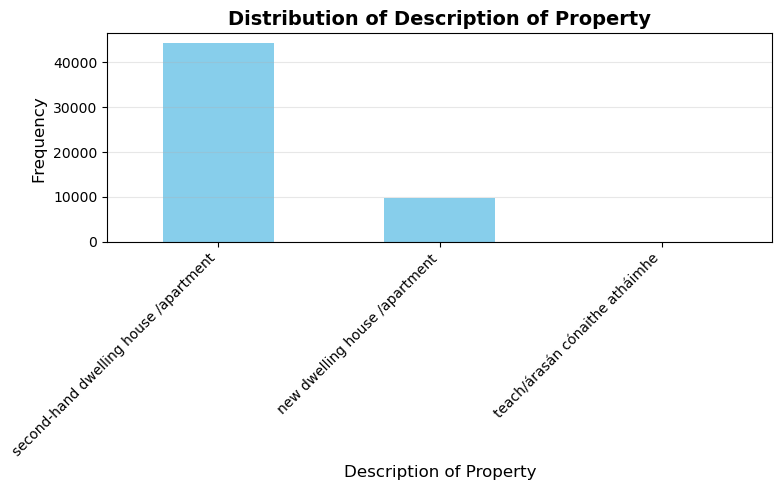

In [204]:
# Description of Property
# Third value to add to Second-Hand

plt.figure(figsize=(8, 5))
df_copy['description_of_property'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution of Description of Property', fontsize=14, fontweight='bold')
plt.xlabel('Description of Property', fontsize=12)
plt.ylabel('Frequency ', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

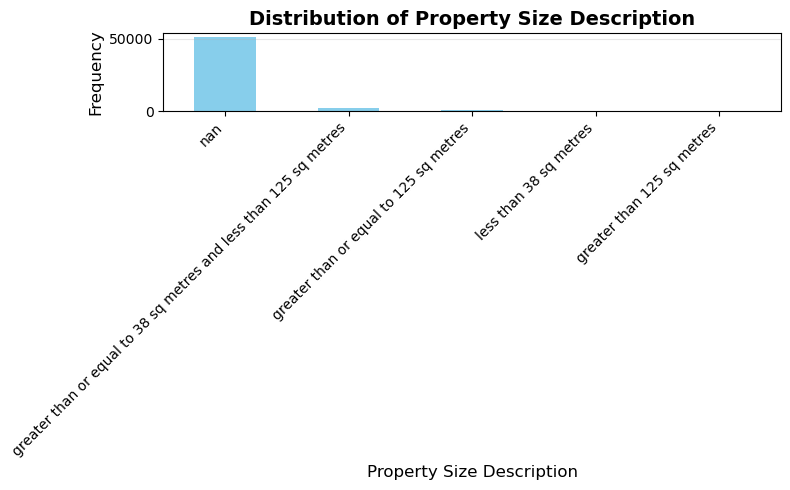

In [205]:
# Property Size Description

plt.figure(figsize=(8, 5))
df_copy['property_size_description'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title('Distribution of Property Size Description', fontsize=14, fontweight='bold')
plt.xlabel('Property Size Description', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

REMARKS ON ALL FEATURES:

- ***Date of Sale***: Category. 
    - **Data Quality issue**=High cardinality. 
    - **Remarks**=Needs to be replaced by other categorical features such as year, month, quarter to have an impact on prediction.


- ***Address***: Category. 
    - **Data Quality Issue**=  High cardinality. 
    - **Remarks**= must be paired with Eircode and/or County to have an impact on prediction.


- ***County***: Category. 
    - **Data Quality Issue**=None. 
    - **Remarks**=No issue, has to paired with other features to create more meaningful features.


- ***Eircode***: Category. 
    - **Data Quality Issue**=High percentage of missing values. 
    - **Remarks**=Investigation into recovery of data for this feature.


- ***Price***: Continuous. 
    - **Data Quality Issue**=Data skewed right => outliers. 
    - **Remarks**=Must be dealt with accordingly (clamping). There also needs to be a distinction between Dublin (perhaps Cork, Galway, Kildare & Meath) data and the rest of the dataset when clamping. Right balance between clamping at small enough area to not mess data, but large enough to be valid. This comes back to "Location" (Address, County, Eircode) feature.


- ***Not Full Market Price***: Category. 
    - **Data Quality Issue**=Singnals incomplete data. 
    - **Remarks**=This is to signal some incomplete data from provider. Investigate whether it is possible to retrieve all data from RPPR. Even so, this data is still not representative of a propertys market value (partial transfer of ownership, gift, affordable housing scheme).


- ***VAT Exclusive***: Category. 
    - **Data Quality Issue**=None. 
    -   **Remarks**= This feature represents the fact that new properties must pay VAT at a rate of 13.5%. It looks to be heavily correlated with Description of Property. Out of 2871 columns with "YES", all of them have an associated Description of Property as "New Dwelling house /Apartment". This follows Irish law which requires VAT on new builds but not second hand.
    For real market price, this VAT rate should be added to properties with a VAT Exclusive value "Yes". Once the adjustements have been made, decide whether to keep this feature or drop it.


- ***Description of Property***: Category. 
    - **Data Quality Issue**=None. 
    - **Remarks**=Seems heavily correlated to VAT Exclusive. Change row with value "Teach/Árasán Cónaithe Atháimhe", there is only one. Because this is a flag, check whether to keep, or create a new boolean value.


- ***Property Size Description***: Category. 
    - **Data Quality Issue**= ~95% missing values. 
    - **Remarks**=Extremely high missing percentage. Would be useful for prediction, but this percentage is too high. Investigate, else drop.

**Step 5: Create new csv file**

In [206]:
# Saving df_copy to new csv

df_copy.to_csv("ppr_group_25275889_train_cleaned.csv", index=False)

# Part 2: Data Quality Plan

| Feature | Type | Data Quality Issue(s) | Impact | Root Cause Analysis | Proposed Solution | Final Action |
|---------|------|----------------------|--------|-------------------|------------------|--------------|
| **Date of sale** | category | High cardinality | High | By design | Replace by other features: month, quarter, year | **Drop** |
| **Address** | category | High cardinality | High | By design | Replace by new feature that takes into account Address, County & Eircode | **Drop**, redundant |
| **County** | category | None identified | Low |  | Can be useful for designin new features if external data is divided by County | **Keep** |
| **Eircode** | category | 69% missing values  | High | Data not collected for all records | Investigate how to use this feature to create a new one | **Drop**, replaced by routing keys |
| **Price** | float64 | Skewed data and outliers | High | Data entry errors | Drop edge values & clamp outliers | **Keep** |
| **Not Full Market Price** | category | Signals incomplete data | High | Flags sales that do not reflect market value | Keep, as test data will have rows with this flag. | **Keep** |
| **VAT Exclusive** | category | Signals VAT must be added to the price | High | New builds require VAT, second-hand builds don't | Perform operation where needed investigate whether this feature needs to be kept | **Drop**, no predicitve value |
| **Description of property** | category | One value has frquency=1; Heavily correlated to VAT Exclusive | Low | No apparent causes | Keep | **KEEP**, turned into boolean value |
| **Property size description** | category | 94% missing values | High | Very little entry | 94% missing values, drop | **Drop**|

In [207]:
try: 
    df = pd.read_csv("ppr_group_25275889_train_cleaned.csv", 
                     keep_default_na=True, 
                     delimiter=',', 
                     skipinitialspace=True)
    
    print(f"✓ Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
    
    # Show the first few rows in the data frame
    display(df.head(3))

except FileNotFoundError:
    print("The file ppr-group-25275889-test.csv was not found in the current directory")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

✓ Successfully loaded dataset with 53989 rows and 9 columns


,date_of_sale,address,county,eircode,price,not_full_market_price,vat_exclusive,description_of_property,property_size_description
0,2016-05-06,4 millbourne close slane rd ashbourne,meath,NaN,249969.16,no,yes,new dwelling house /apartment,greater than or equal to 38 sq metres and less...
1,2016-12-09,26 parkside dr balgriffin dublin 13,dublin,NaN,281931.72,no,yes,new dwelling house /apartment,greater than or equal to 38 sq metres and less...
2,2016-04-07,apt 2 fitzgerald ct callan louth,louth,NaN,75000.00,no,no,second-hand dwelling house /apartment,NaN


In [208]:
# Looking at shape of the dataset

print("There are", df.shape[0], "rows in the dataset")
print("There are", df.shape[1], "columns in the dataset")

print("There are", df.duplicated().sum(), "duplicates in the dataset")

There are 53989 rows in the dataset
There are 9 columns in the dataset
There are 0 duplicates in the dataset


Create a copy of the Dataframe

In [209]:
df_copy = df.copy()

Convert features if they haven't been converted yet

In [210]:
# Convert all object columns to categorical
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

/var/folders/sf/cpst0jxn09170tcq8lkwcsjr0000gn/T/ipykernel_22242/1606462660.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object').columns:


In [211]:
numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns

In [212]:
# Summary: Show feature categorization results
print("="*70)
print("FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT")
print("="*70)
print(f"\n✓ Numeric features ({len(numeric_columns)}):")
print(f"   {list(numeric_columns)}")
print(f"\n✓ Categorical features ({len(category_columns)}):")
print(f"   {list(category_columns)}")
print("\n" + "="*70)

FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT

✓ Numeric features (1):
   ['price']

✓ Categorical features (8):
   ['date_of_sale', 'address', 'county', 'eircode', 'not_full_market_price', 'vat_exclusive', 'description_of_property', 'property_size_description']



## Investigation of all features and implementing strategies based on the Data Quality Table above

1. Investigate Not Full Market Price feature & keeping it as a boolean flag
2. Change Date of Sale feature to Month, Quarter, Year features. 
3. Change Address, County, Eircode to new feature based on the routing key table
4. Drop Address & Eircode features. Keep County for now as it does not have high cardinality and no missing values. 
5. Normalise all new houses with VAT exclusive to Gross price (+13.5%) & drop feature
6. Drop any houses above 10 Million
7. Drop any house below 30 Thousand 
8. Revert back to county any area codes that have less than 30 sales 
9. Clamp outliers based on their area code
10. Create log price feature to reduce the impact of outliers
11. Fix the value in Irish in "description of property"
12. Drop Property Size Description feature


1. Investigate Not Full Market Price feature and create a boolean flag 

In [213]:
not_full_market_price = df.loc[df["not_full_market_price"] == "yes"]
yes_price = not_full_market_price["price"]
yes_price.describe()

print(yes_price.count(), "rows are Not Full Market Price")
print("Mean: ", yes_price.mean().__round__(2), "€")
print("1st Quartile: ", yes_price.quantile(0.25).__round__(2), "€")
print("Median: ", yes_price.median().__round__(2), "€")
print("3rd Quartile: ", yes_price.quantile(0.75).__round__(2), "€")


2867 rows are Not Full Market Price
Mean:  298617.53 €
1st Quartile:  91420.0 €
Median:  168304.11 €
3rd Quartile:  250122.37 €


In [214]:
full_market_price = df.loc[df["not_full_market_price"] == "no"]
no_price = full_market_price["price"]
no_price.describe()

print(no_price.count(), "rows are Full Market Price")
print("Mean: ", no_price.mean().__round__(2), "€")
print("1st Quartile: ", no_price.quantile(0.25).__round__(2), "€")
print("Median: ", no_price.median().__round__(2), "€")
print("3rd Quartile: ", no_price.quantile(0.75).__round__(2), "€")

51122 rows are Full Market Price
Mean:  325414.72 €
1st Quartile:  162000.0 €
Median:  256000.0 €
3rd Quartile:  370044.05 €


In [215]:
if "is_full_market_price" not in df.columns:
    df["is_full_market_price"] = df["not_full_market_price"].str.lower().map({'no': 1, 'yes': 0}).astype(int)  
    df["is_full_market_price"] = df["is_full_market_price"].astype("category")  
    print("Column 'is_full_market_price' successfully changed")
else:
    print("Column 'is_full_market_price' already changed")

Column 'is_full_market_price' successfully changed


In [216]:
if "not_full_market_price" in df.columns:
    df = df.drop(columns="not_full_market_price")
    print("Column 'not_full_market_price' successfully dropped")
else:
    print("Column 'not_full_market_price' already dropped")

Column 'not_full_market_price' successfully dropped


2. Change Date of Sale feature to Month, Quarter, Year features. 

In [217]:
if 'date_of_sale' in df.columns:

    # converting date of sale to a datetime object
    df["date_of_sale"] = pd.to_datetime(df["date_of_sale"])
    # df["date_of_sale"] = pd.to_datetime(df["date_of_sale"], dayfirst=True)
    print("Column 'date of sale' has been successfully converted")

    # converting month and quarter to categorical features
    df['month'] = df['date_of_sale'].dt.month.astype('category')
    print("Column 'month' has been successfully created")

    df['quarter'] = df["date_of_sale"].dt.quarter.astype('category')
    print("Column 'quarter' has been successfully created")

    # converting year to a numeric feature
    df['year'] = df["date_of_sale"].dt.year
    print("Column 'year' has been successfully created")

    # dropping date of sale column
    df = df.drop(columns=['date_of_sale'])
    print("Column 'date_of_sale' successfully dropped.")
else:
    print("New features already created and 'date of sale' column already dropped.")

Column 'date of sale' has been successfully converted
Column 'month' has been successfully created
Column 'quarter' has been successfully created
Column 'year' has been successfully created
Column 'date_of_sale' successfully dropped.


3. Change Address, County, Eircode to new feature based on the routing key table


In [218]:
town_to_key = {
    ('youghal', 'cork'): 'p36',
    ('wicklow', 'wicklow'): 'a67',
    ('whitechurch', 'cork'): 't34',
    ('wexford', 'wexford'): 'y35',
    ('westport', 'mayo'): 'f28',
    ('watergrasshill', 'cork'): 't56',
    ('waterford', 'waterford'): 'x91',
    ('virginia', 'cavan'): 'a82',
    ('tullamore', 'offaly'): 'r35',
    ('tuam', 'galway'): 'h54',
    ('tralee', 'kerry'): 'v92',
    ('tipperary', 'tipperary'): 'e34',
    ('thurles', 'tipperary'): 'e41',
    ('swords', 'dublin'): 'k67',
    ('dublin airport', 'dublin'): 'k67',
    ('summerhill', 'meath'): 'a83',
    ('sligo', 'sligo'): 'f91',
    ('skibbereen', 'cork'): 'p81',
    ('skerries', 'dublin'): 'k34',
    ('shannon', 'clare'): 'v14',
    ('rush', 'dublin'): 'k56',
    ('roscrea', 'tipperary'): 'e53',
    ('roscommon', 'roscommon'): 'f42',
    ('ratoath', 'meath'): 'a85',
    ('rathnew', 'wicklow'): 'a67',
    ('portlaoise', 'laois'): 'r32',
    ('oldtown', 'dublin'): 'a45',
    ('newtownmountkennedy', 'wicklow'): 'a63',
    ('newcastle west', 'limerick'): 'v42',
    ('newcastle', 'wicklow'): 'a63',
    ('newbridge', 'kildare'): 'w12',
    ('new ross', 'wexford'): 'y34',
    ('nenagh', 'tipperary'): 'e45',
    ('navan', 'meath'): 'c15',
    ('naas', 'kildare'): 'w91',
    ('mullingar', 'westmeath'): 'n91',
    ('muine bheag', 'carlow'): 'r21',
    ('monkstown', 'dublin'): 'a94',
    ('monasterevin', 'kildare'): 'w34',
    ('monaghan', 'monaghan'): 'h18',
    ('mitchelstown', 'cork'): 'p67',
    ('midleton', 'cork'): 'p25',
    ('maynooth', 'kildare'): 'w23',
    ('mallow', 'cork'): 'p51',
    ('malahide', 'dublin'): 'k36',
    ('macroom', 'cork'): 'p12',
    ('lusk', 'dublin'): 'k45',
    ('lucan', 'dublin'): 'k78',
    ('loughrea', 'galway'): 'h62',
    ('longford', 'longford'): 'n39',
    ('little island', 'cork'): 't45',
    ('listowel', 'kerry'): 'v31',
    ('limerick', 'limerick'): 'v94',
    ('lifford', 'donegal'): 'f93',
    ('letterkenny', 'donegal'): 'f92',
    ('laytown', 'meath'): 'a92',
    ('bettystown', 'meath'): 'a92',
    ('mornington', 'meath'): 'a92',
    ('kinsale', 'cork'): 'p17',
    ('kingscourt', 'cavan'): 'a82',
    ('kilrush', 'clare'): 'v15',
    ('kilmallock', 'limerick'): 'v35',
    ('kilmacthomas', 'waterford'): 'x42',
    ('killarney', 'kerry'): 'v93',
    ('kilkenny', 'kilkenny'): 'r95',
    ('kildare', 'kildare'): 'r51',
    ('kilcoole', 'wicklow'): 'a63',
    ('kells', 'meath'): 'a82',
    ('greystones', 'wicklow'): 'a63',
    ('gorey', 'wexford'): 'y25',
    ('glenageary', 'dublin'): 'a96',
    ('garristown', 'dublin'): 'a42',
    ('galway', 'galway'): 'h91',
    ('fermoy', 'cork'): 'p61',
    ('enniscorthy', 'wexford'): 'y21',
    ('ennis', 'clare'): 'v95',
    ('enfield', 'meath'): 'a83',
    ('edenderry', 'offaly'): 'r45',
    ('dunshaughlin', 'meath'): 'a85',
    ('dunmanway', 'cork'): 'p47',
    ('dungarvan', 'waterford'): 'x35',
    ('dundalk', 'louth'): 'a91',
    ('dunboyne', 'meath'): 'a86',
    ('drogheda', 'louth'): 'a92',
    ('donoughmore', 'cork'): 'p32',
    ('donegal', 'donegal'): 'f94',
    ('delgany', 'wicklow'): 'a63',
    ('curragh camp', 'kildare'): 'r56',
    ('crookstown', 'cork'): 'p14',
    ('cootehill', 'cavan'): 'h16',
    ('cobh', 'cork'): 'p24',
    ('clonmel', 'tipperary'): 'e91',
    ('clones', 'monaghan'): 'h23',
    ('clonakilty', 'cork'): 'p85',
    ('clifden', 'galway'): 'h71',
    ('claremorris', 'mayo'): 'f12',
    ('charleville', 'cork'): 'p56',
    ('cavan', 'cavan'): 'h12',
    ('castlerea', 'roscommon'): 'f45',
    ('castleblaney', 'monaghan'): 'a75',
    ('castlebar', 'mayo'): 'f23',
    ('cashel', 'tipperary'): 'e25',
    ('carrigaline', 'cork'): 'p43',
    ('carrickmacross', 'monaghan'): 'a81',
    ('carrick-on-suir', 'tipperary'): 'e32',
    ('carrick-on-shannon', 'leitrim'): 'n41',
    ('carlow', 'carlow'): 'r93',
    ('cahir', 'tipperary'): 'e21',
    ('caherciveen', 'kerry'): 'v23',
    ('bray', 'wicklow'): 'a98',
    ('boyle', 'roscommon'): 'f52',
    ('booterstown', 'dublin'): 'a94',
    ('blackrock', 'dublin'): 'a94',
    ('birr', 'offaly'): 'r42',
    ('belturbet', 'cavan'): 'h14',
    ('bantry', 'cork'): 'p75',
    ('bandon', 'cork'): 'p72',
    ('ballymote', 'sligo'): 'f56',
    ('ballyhaunis', 'mayo'): 'f35',
    ('ballyboughal', 'dublin'): 'a41',
    ('ballybay', 'monaghan'): 'a75',
    ('ballinrobe', 'mayo'): 'f31',
    ('ballincollig', 'cork'): 'p31',
    ('ballinasloe', 'galway'): 'h53',
    ('ballina', 'mayo'): 'f26',
    ('balbriggan', 'dublin'): 'k32',
    ('athy', 'kildare'): 'r14',
    ('athlone', 'westmeath'): 'n37',
    ('athenry', 'galway'): 'h65',
    ('ashbourne', 'meath'): 'a84',
    ('arklow', 'wicklow'): 'y14',
    ('ardee', 'louth'): 'a92',
    ('blackrock', 'dublin'): 'a94',
    ('monkstown', 'dublin'): 'a94',
    ('booterstown', 'dublin'): 'a94',
    ('dalkey', 'dublin'): 'a96',
    ('killiney', 'dublin'): 'a96',
    ('sandycove', 'dublin'): 'a96',
    ('clontarf', 'dublin'): 'd03',
    ('ballsbridge', 'dublin'): 'd04',
    ('donnybrook', 'dublin'): 'd04',
    ('rathmines', 'dublin'): 'd06',
    ('ranelagh', 'dublin'): 'd06',
    ('phibsborough', 'dublin'): 'd07',
    ('smithfield', 'dublin'): 'd07',
    ('stoneybatter', 'dublin'): 'd07',
    ('ballyfermot', 'dublin'): 'd10',
    ('finglas', 'dublin'): 'd11',
    ('castleknock', 'dublin'): 'd15',
    ('dundrum', 'dublin'): 'd14',
    ('goatstown', 'dublin'): 'd14',
    ('sutton', 'dublin'): 'd13',
    ('howth', 'dublin'): 'd13',
    ('portmarnock', 'dublin'): 'd13',
    ('douglas', 'cork'): 't12',
    ('rochestown', 'cork'): 't12',
    ('ballinlough', 'cork'): 't12',
    ('blackpool', 'cork'): 't23',
    ('ballyvolane', 'cork'): 't23',
    ('glanmire', 'cork'): 't45',
    ('cloyne', 'cork'): 'p25',
    ('celbridge', 'kildare'): 'w23',
    ('leixlip', 'kildare'): 'w23',
    ('kilcock', 'kildare'): 'w23',
    ('kildare town', 'kildare'): 'r51',
    ('sallins', 'kildare'): 'w91',
    ('clane', 'kildare'): 'w91',
    ('trim', 'meath'): 'c15',
    ('oldcastle', 'meath'): 'a82',
    ('stamullen', 'meath'): 'k32',
    ('kenmare', 'kerry'): 'v93',
    ('castleisland', 'kerry'): 'v92',
    ('killorglin', 'kerry'): 'v93',
    ('dingle', 'kerry'): 'v92',
    ('shannon', 'clare'): 'v14',
    ('ennis', 'clare'): 'v95',
    ('kilrush', 'clare'): 'v15',
    ('sixmilebridge', 'clare'): 'v95',
    ('killaloe', 'clare'): 'v94',
    ('castletroy', 'limerick'): 'v94',
    ('raheen', 'limerick'): 'v94',
    ('dooradoyle', 'limerick'): 'v94',
    ('adare', 'limerick'): 'v94',
    ('abbeyfeale', 'limerick'): 'v94',
    ('newcastle west', 'limerick'): 'v42'
}

In [219]:

df["area_code"] = ''

def infer_area_codes(row):
    # Prioritize Eircode if it exists
    if pd.notnull(row['eircode']) and len(str(row['eircode'])) >= 3:
        return str(row['eircode'])[:3].strip()
    
    addr = str(row['address']).lower()
    cty = str(row['county']).lower()
    
    # Check for dublin first 
    dub_match = re.search(r'dublin (\d+|6w)', addr)
    if dub_match:
        val = dub_match.group(1)
        return f"d{val.zfill(2)}" if val != '6w' else 'd6w'
    
    # Then check in the dictionary
    for (town, county), key in town_to_key.items():
        if town in addr and county == cty:
            return key
            
    return "gen_" + cty

# Run the function
df['area_code'] = df.apply(infer_area_codes, axis=1)

total = len(df)
unknown_count = df['area_code'].str.contains('gen').sum()
success_count = total - unknown_count

print(f"Total Rows: {total}")
print(f"Successfully Mapped to a Key: {success_count} ({ (success_count/total)*100:.2f}%)")
print(f"Mapped to General County: {unknown_count} ({ (unknown_count/total)*100:.2f}%)")

if unknown_count > 0:
    print("\nCounties with most 'General' mappings (would need more town entries):")
    print(df[df['area_code'].str.contains('gen')]['county'].value_counts().head(5))

Total Rows: 53989
Successfully Mapped to a Key: 42344 (78.43%)
Mapped to General County: 11645 (21.57%)

Counties with most 'General' mappings (would need more town entries):
county
dublin     3213
cork       2104
meath       513
kildare     446
clare       429
Name: count, dtype: int64


In [220]:
# Running function to compare Eircode with guesses

test_df = df[df['eircode'].notna()].copy()


def test_inference(row):
    addr = str(row['address']).lower()
    cty = str(row['county']).lower()
    # Ignore Eircodes 
    
    # Regex Dublin
    dub_match = re.search(r'dublin (\d+|6w)', addr)
    if dub_match:
        val = dub_match.group(1)
        return f"d{val.zfill(2)}" if val != '6w' else 'd6w'
    
    # Check in dictionary
    for (town, county), key in town_to_key.items():
        if town in addr and county == cty:
            return key
            
    return "gen_" + cty

# Run test
test_df['blind_guess'] = test_df.apply(test_inference, axis=1)
test_df['actual_code'] = test_df['eircode'].str.strip().str[:3]

matches = (test_df['blind_guess'] == test_df['actual_code']).sum()
accuracy = (matches / len(test_df)) * 100

print(f"When forced to guess without an Eircode, the code was correct {accuracy:.2f}% of the time.")

# Comparing mapping of eircodes to fallback on county
print("\nBreakdown of results:")
print(test_df['blind_guess'].str.contains('gen').value_counts().rename({True: 'Failed (Returned GEN)', False: 'Attempted a Mapping'}))

When forced to guess without an Eircode, the code was correct 64.66% of the time.

Breakdown of results:
blind_guess
Attempted a Mapping      12682
Failed (Returned GEN)     4221
Name: count, dtype: int64


In [221]:
# Filter for rows where the code tried to guess but got it WRONG
hard_errors = test_df[(test_df['blind_guess'] != test_df['actual_code']) & 
                      (~test_df['blind_guess'].str.contains('gen'))]

print(f"Hard Errors (Wrong Guess): {len(hard_errors)}")
print(f"Soft Errors (Gave up/GEN): {len(test_df[test_df['blind_guess'].str.contains('gen')])}")

pctg_hard_errors = (len(hard_errors)/len(test_df)) * 100
print(f"\nOut of {len(test_df)} possible mappings, the code tried to map and failed on {pctg_hard_errors.__round__(2)}% of guesses")

# See the top 'Hard Errors' to find dictionary overlaps
print("\nTop 10 Dictionary Hard Errors:")
print(hard_errors[['address', 'actual_code', 'blind_guess']].head(10))
print("="*80)

Hard Errors (Wrong Guess): 1752
Soft Errors (Gave up/GEN): 4221

Out of 16903 possible mappings, the code tried to map and failed on 10.37% of guesses

Top 10 Dictionary Hard Errors:
                                           address actual_code blind_guess
5494              39 hughes mill clonmel tipperary         e91         e34
7593                 cooldross la kilcoole wicklow         a63         a67
12669              18 woodview ballieborough cavan         a82         h12
18160               18 mountain rd cahir tipperary         e21         e34
22253        1 coastguard station rosslare wexford         y25         y35
24670        7 charlesland wood greystones wicklow         a63         a67
25480                     60 quay st dundalk louth         v91         a91
25483                  rathkenny fethard tipperary         e91         e34
29744        1 coastguard cove arthurstown wexford         y34         y35
30052  11 cambria de vesci ct the slopes monkstown         a96     

HOWEVER, after analysing the top 10 errors above:
- The blind guess was correct twice, which means the error was in data entry.
- All other 8 guesses were mapped to the routing key from the town which has the same name as the county (Tipperary, Tipperary; Wexford, Wexford). Tweaks to the code were performed to account for this, but none amounted to a percentage as high as this code. 
- No blind guess was mapped to a routing key from another county.

While this is not ideal, and extrapolating this to the entire dataset would be erroneous, the routing key feature provides our model with much more granular information with minimal errors. The decision was taken to keep this feature. 

In [222]:
# Changing area_code data type from object to categorical
df["area_code"] = df["area_code"].astype('category') 

4. Drop Address & Eircode features. Keep County for now as it does not have high cardinality and no missing values.

In [223]:
if "eircode" in df.columns:
    df = df.drop(columns="eircode")
    print("Column 'eircode' successfully dropped")
else:
    print("Column 'eircode' already dropped")

Column 'eircode' successfully dropped


In [224]:
if "address" in df.columns:
    df = df.drop(columns="address")
    print("Column 'address' successfully dropped")
else:
    print("Column 'address' already dropped")

Column 'address' successfully dropped


5. Normalise all new houses with VAT exclusive to Gross price (+13.5%) & drop feature

In [225]:
# Put in some code showing before VAT added
pre_vat = df["price"]
print("Before adding VAT to the builds:")
print("Mean: ", pre_vat.mean().__round__(2), "€")
print("1st Quartile: ", pre_vat.quantile(0.25).__round__(2), "€")
print("Median: ", pre_vat.median().__round__(2), "€")
print("3rd Quartile: ", pre_vat.quantile(0.75).__round__(2), "€")

Before adding VAT to the builds:
Mean:  323991.7 €
1st Quartile:  157500.0 €
Median:  250000.0 €
3rd Quartile:  365000.0 €


In [226]:
rows_to_update = df[df["vat_exclusive"] == "yes"].shape[0]
if rows_to_update > 0:
    df.loc[df["vat_exclusive"] == "yes", "price"] *= 1.135

In [227]:
# code showing post VAT
post_vat = df["price"]
print("After adding VAT to the builds:")
print("Mean: ", post_vat.mean().__round__(2), "€")
print("1st Quartile: ", post_vat.quantile(0.25).__round__(2), "€")
print("Median: ", post_vat.median().__round__(2), "€")
print("3rd Quartile: ", post_vat.quantile(0.75).__round__(2), "€")

After adding VAT to the builds:
Mean:  334062.11 €
1st Quartile:  160000.0 €
Median:  259000.0 €
3rd Quartile:  380000.0 €


In [228]:
if "vat_exclusive" in df.columns:
    df = df.drop(columns="vat_exclusive")
    print("Column 'vat_exclusive' successfully dropped")
else:
    print("Column 'vat_exclusive' already dropped")

Column 'vat_exclusive' successfully dropped


Creating log price to visualise normality

In [229]:
log_price = np.log(df["price"])

6. Drop any houses above 10 Million 
7. Drop any house below 30 Thousand 

In [230]:
price = df["price"]

In [231]:
# dropping rows that are above 10 Million
upper_limit = 10000000
above_10_M = price > int(upper_limit)
number_above_10_M = above_10_M.sum()
number_above_10_M

rows_to_drop = df[above_10_M].index
if number_above_10_M > 0:
    print(f"Dropping {len(rows_to_drop)} row(s):")
    print(f"  Indices: {list(rows_to_drop)}")
    df = df.drop(rows_to_drop)
else:
    print("Builds above 10 Million have already been dropped")

Dropping 36 row(s):
  Indices: [3118, 5126, 15296, 15717, 16024, 17791, 19291, 21852, 23431, 24678, 29793, 31723, 32929, 33389, 34504, 34729, 36392, 36617, 36666, 38034, 38336, 40100, 40333, 41384, 43185, 43264, 43506, 44457, 45688, 49073, 49813, 50339, 50718, 51891, 53213, 53270]


In [232]:
# dropping rows that are below 30K
lower_limit = 30000
below_30k = price < int(lower_limit)
number_below_30k = below_30k.sum()
number_below_30k

rows_to_drop = df[below_30k].index
if number_below_30k > 0:
    print(f"Dropping {len(rows_to_drop)} row(s):")
    print(f"  Indices: {list(rows_to_drop)}")
    df = df.drop(rows_to_drop)
else:
    print("Builds below 30 Thousand have already been dropped")

Dropping 595 row(s):
  Indices: [266, 293, 329, 356, 433, 570, 581, 584, 641, 671, 682, 857, 863, 956, 978, 1014, 1044, 1046, 1092, 1099, 1158, 1165, 1208, 1236, 1239, 1296, 1302, 1340, 1407, 1438, 1551, 1605, 1615, 1621, 1633, 1672, 1673, 1761, 1768, 1808, 1868, 1924, 1966, 1977, 2011, 2035, 2055, 2107, 2141, 2173, 2279, 2298, 2383, 2405, 2436, 2509, 2625, 2677, 2766, 2809, 2811, 2933, 2955, 3027, 3073, 3153, 3184, 3212, 3217, 3218, 3320, 3377, 3392, 3398, 3422, 3455, 3465, 3559, 3560, 3618, 3688, 3693, 3756, 3915, 3921, 3962, 3998, 4003, 4022, 4041, 4045, 4051, 4059, 4080, 4106, 4146, 4154, 4171, 4175, 4254, 4299, 4304, 4499, 4591, 4611, 4622, 4629, 4638, 4660, 4760, 4816, 4846, 4858, 5034, 5039, 5174, 5203, 5223, 5263, 5314, 5388, 5398, 5422, 5557, 5568, 5625, 5677, 5711, 5767, 5790, 5799, 5820, 5835, 5849, 5854, 6121, 6226, 6239, 6248, 6333, 6512, 6550, 6564, 6681, 6777, 6811, 6813, 6862, 6883, 6922, 7013, 7082, 7125, 7152, 7182, 7228, 7313, 7349, 7407, 7457, 7483, 7597, 7640, 7662

/var/folders/sf/cpst0jxn09170tcq8lkwcsjr0000gn/T/ipykernel_22242/3020775827.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rows_to_drop = df[below_30k].index


8. Revert back to county area codes that have less than 30 sales 

In [233]:
# reverting all area codes less than 30 to their original county
area_code_counts = df["area_code"].value_counts()

threshold = 30

unreliable_codes = area_code_counts[area_code_counts < threshold].index

mask = df["area_code"].isin(unreliable_codes)
df.loc[mask, "area_code"] = "gen_" + df["county"].str.replace(" ", "")

print("Reverted", mask.sum(), "rows back to their original county")

Reverted 202 rows back to their original county


9. Clamp outliers based on their area code (the new feature created)

In [234]:
# UPPER OUTLIERS
df['regional_clamp'] = df.groupby('area_code')['price'].transform(lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))


df['price'] = np.where(
    df['price'] > df['regional_clamp'], 
    df['regional_clamp'], 
    df['price']
)

# count how many values were actually clamped
clamped_count = (df['price'] == df['regional_clamp']).sum()
print(f"Successfully clamped {clamped_count} outliers.")

# remove the regional_clamp column 
df = df.drop(columns=['regional_clamp'])

Successfully clamped 2149 outliers.


In [235]:
# LOWER OUTLIERS
df['regional_clamp'] = df.groupby('area_code')['price'].transform(lambda x: x.quantile(0.25) - 1.5 * (x.quantile(0.75) - x.quantile(0.25)))


df['price'] = np.where(
    df['price'] < df['regional_clamp'], 
    df['regional_clamp'], 
    df['price']
)

# count how many values were actually clamped
clamped_count = (df['price'] == df['regional_clamp']).sum()
print(f"Successfully clamped {clamped_count} outliers.")

# remove the regional_clamp column 
df = df.drop(columns=['regional_clamp'])

Successfully clamped 23 outliers.


10. Checking new log price and creating log price feature

In [236]:
new_log_price = np.log(df["price"])

In [237]:
if "log_price" not in df.columns:
    df["log_price"] = np.log(df["price"])
    print("Column 'log_price' successfully created")
else:
    print("Column 'log_price' already created")

Column 'log_price' successfully created


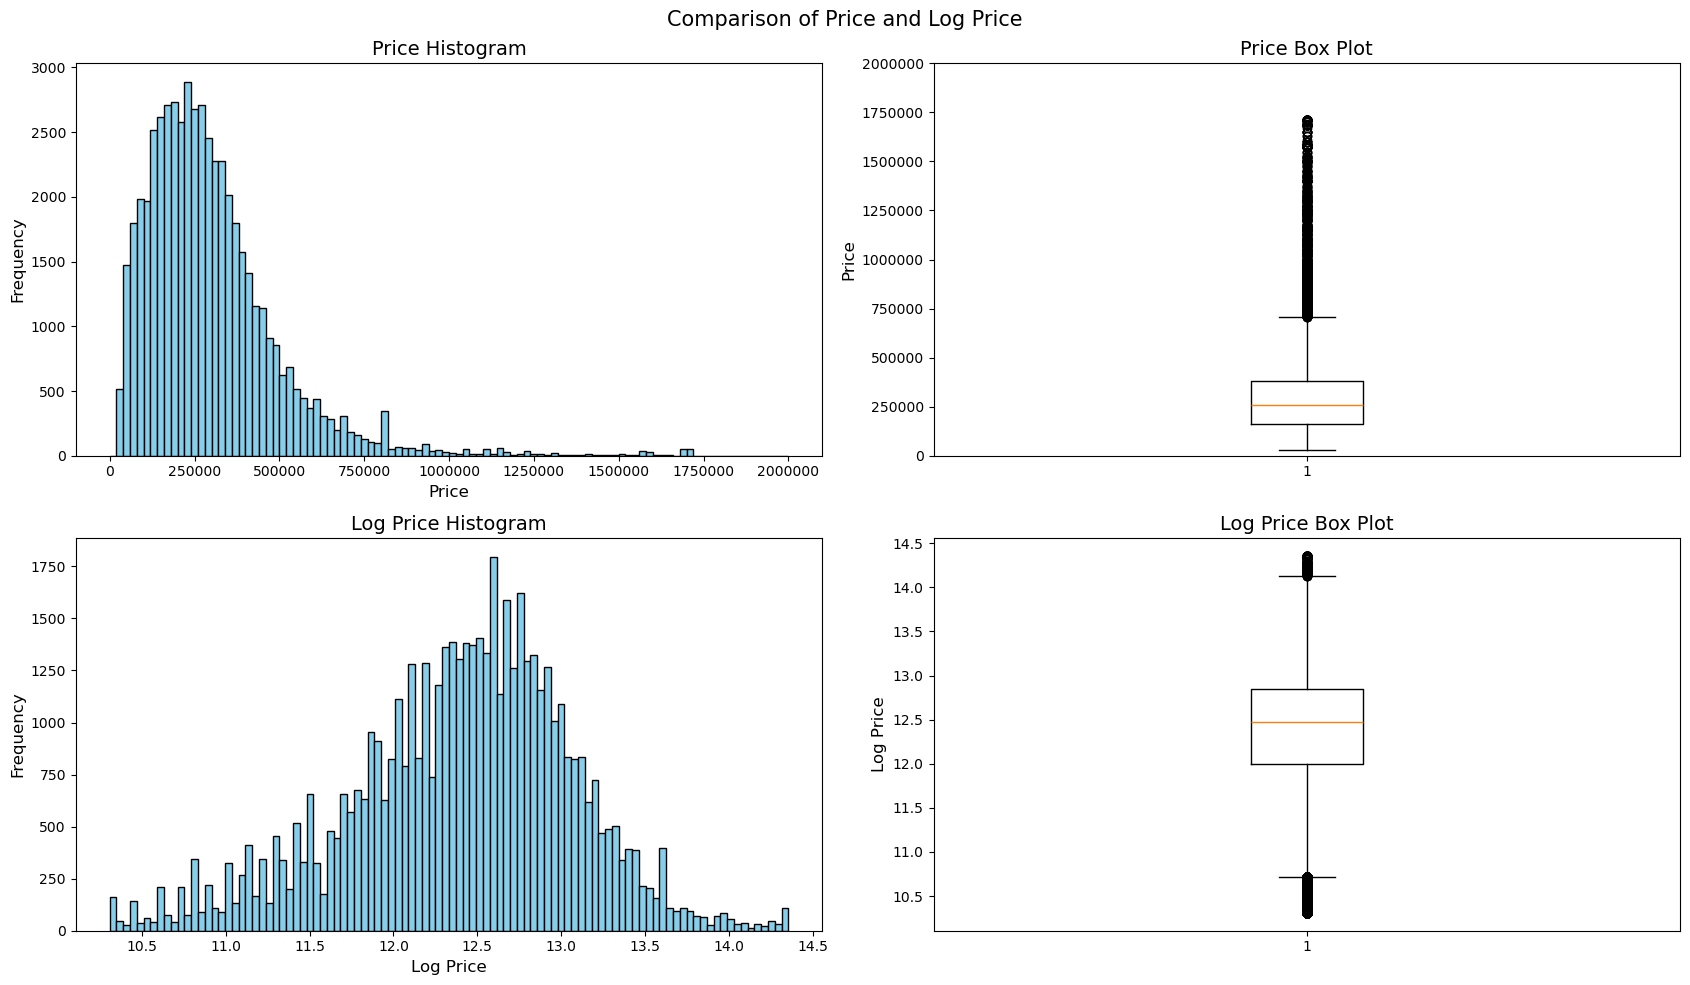

In [238]:
# Plotting both Price and Log Price

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Comparison of Price and Log Price", fontsize=15)

# Price

# Histogram
axes[0, 0].hist(df["price"], bins=100, color="skyblue", edgecolor="black", range=(0, 2_000_000))
axes[0, 0].set_xlabel('Price', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Price Histogram', fontsize=14)
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[0, 1].boxplot(df["price"])
axes[0, 1].set_ylim(0, 2_000_000)
axes[0, 1].set_title('Price Box Plot', fontsize=14)
axes[0, 1].set_ylabel('Price', fontsize=12)
axes[0, 1].ticklabel_format(style='plain', axis='y')

###################################################

# Gross price

# Histogram
axes[1, 0].hist(df["log_price"], bins=100, color="skyblue", edgecolor="black")
axes[1, 0].set_xlabel('Log Price', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Log Price Histogram', fontsize=14)
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Box Plot
axes[1, 1].boxplot(df["log_price"])
axes[1, 1].set_title('Log Price Box Plot', fontsize=14)
axes[1, 1].set_ylabel('Log Price', fontsize=12)
axes[1, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

11. Fix the value in Irish in "description of property"

In [239]:
irish = (df["description_of_property"] != "second-hand dwelling house /apartment") & (df["description_of_property"] != "new dwelling house /apartment")

df.loc[irish, "description_of_property"] = "second-hand dwelling house /apartment"

Change description of property to be a boolean feature

In [240]:
if "is_new" not in df.columns:
    df["is_new"] = df["description_of_property"].str.lower().str.startswith("new", na=False).astype(int)
    df["is_new"] = df["is_new"].astype("category")
    print("Column 'is_new' successfully created")
else:
    print("Column 'is_new' already created")

Column 'is_new' successfully created


In [241]:
if "description_of_property" in df.columns:
    df = df.drop(columns="description_of_property")
    print("Column 'description_of_property' successfully dropped")
else:
    print("Column 'desscription_of_property' already dropped")

Column 'description_of_property' successfully dropped


12. Drop Property Size Description feature because 94% missing values

In [242]:
if "property_size_description" in df.columns:
    df = df.drop(columns="property_size_description")
    print("Column 'property_size_description' successfully dropped")
else:
    print("Column 'property_size_description' already dropped ")

Column 'property_size_description' successfully dropped


In [243]:
df.dtypes

county                  category
price                    float64
is_full_market_price    category
month                   category
quarter                 category
year                       int32
area_code               category
log_price                float64
is_new                  category
dtype: object

Checking if there are any missing values

In [244]:
total_missing = df.isnull().sum().sum()

if total_missing == 0:
    print("There are", total_missing, "missing values. The dataset is clean.")
else:
    print("There are still", total_missing,"missing values to handle.")

There are 0 missing values. The dataset is clean.


SAVE DATAFRAME TO CSV

In [245]:
# Saving df_copy to new csv
df.to_csv("ppr_group_25275889_train_cleaned_final.csv", index=False)

# Part 3: Feature Pairs 

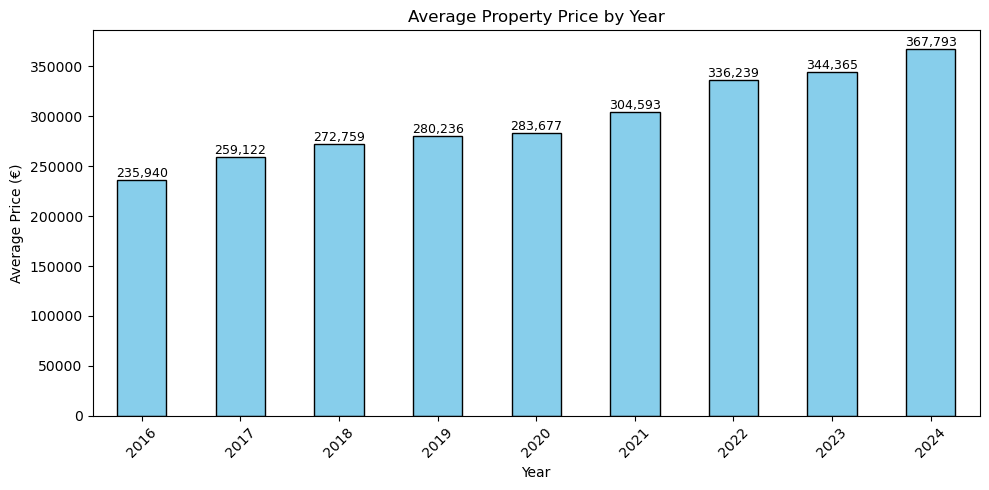

Overall increase: 55.88%


In [246]:
import matplotlib.pyplot as plt

avg_price_year = df.groupby('year')['price'].mean().sort_index()

ax = avg_price_year.plot(kind='bar', figsize=(10,5), color='skyblue', edgecolor='black')

plt.title('Average Property Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price (€)')

# Add labels on each bar
for i, v in enumerate(avg_price_year):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

growth = (avg_price_year.iloc[-1] / avg_price_year.iloc[0] - 1) * 100
print(f"Overall increase: {growth:.2f}%")

The average property price rose 55.88% between 2016 and 2024.

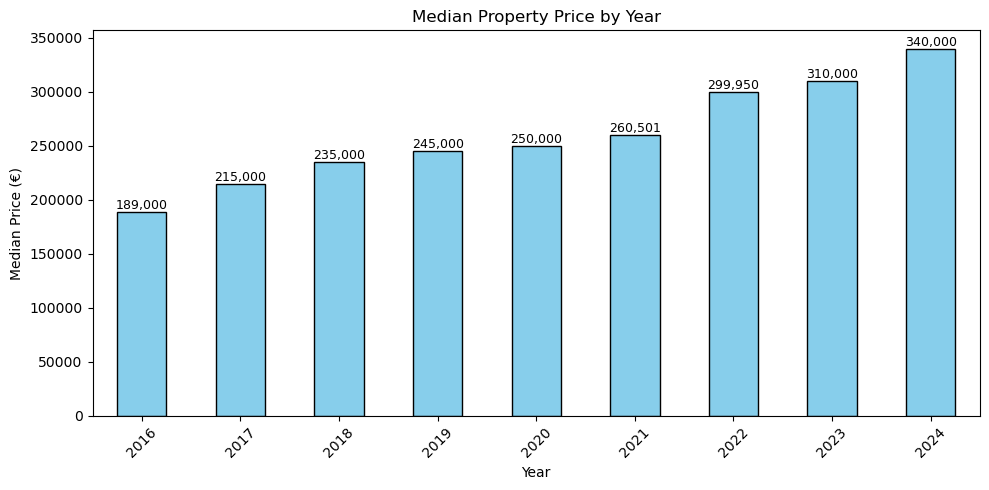

Overall increase: 79.89%


In [247]:
import matplotlib.pyplot as plt

median_price_year = df.groupby('year')['price'].median().sort_index()

ax = median_price_year.plot(kind='bar', figsize=(10,5), color='skyblue', edgecolor='black')

plt.title('Median Property Price by Year')
plt.xlabel('Year')
plt.ylabel('Median Price (€)')

# Add labels on each bar
for i, v in enumerate(median_price_year):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

growth = (median_price_year.iloc[-1] / median_price_year.iloc[0] - 1) * 100
print(f"Overall increase: {growth:.2f}%")

The median property price rose 79.89% from 2016 to 2024, showing a more significant change compared to the increase in average price. 

In [248]:
import numpy as np

county_trends = {}

for county in df['county'].unique():
    subset = df[df['county'] == county]
    avg_prices = subset.groupby('year')['price'].mean()

    # Only compute if enough data points
    if len(avg_prices) > 1:
        slope = np.polyfit(avg_prices.index, avg_prices.values, 1)[0]
        county_trends[county] = slope

# Convert to sorted list
sorted_trends = sorted(county_trends.items(), key=lambda x: x[1])

print("Counties with lowest trends:")
for c in sorted_trends[:10]:
    print(c)

Counties with lowest trends:
('monaghan', np.float64(9495.395942855235))
('donegal', np.float64(9843.570415608028))
('roscommon', np.float64(10767.331506372122))
('longford', np.float64(11372.261258250133))
('leitrim', np.float64(11657.653062693567))
('sligo', np.float64(11718.332931818315))
('mayo', np.float64(12065.449730590795))
('tipperary', np.float64(12188.320765300763))
('cavan', np.float64(12750.185725473522))
('kerry', np.float64(13755.023161064595))


In [249]:
# Top 5 fastest growing
print("Fastest growing counties:")
for c in sorted(county_trends, key=county_trends.get, reverse=True)[:5]:
    print(c, county_trends[c])

# Bottom 5 slowest
print("\nSlowest growing counties:")
for c in sorted_trends[:5]:
    print(c)

Fastest growing counties:
westmeath 19647.25939994272
kildare 19329.43218263265
kilkenny 19322.25241036363
wicklow 19209.21605846158
dublin 17053.663783599834

Slowest growing counties:
('monaghan', np.float64(9495.395942855235))
('donegal', np.float64(9843.570415608028))
('roscommon', np.float64(10767.331506372122))
('longford', np.float64(11372.261258250133))
('leitrim', np.float64(11657.653062693567))


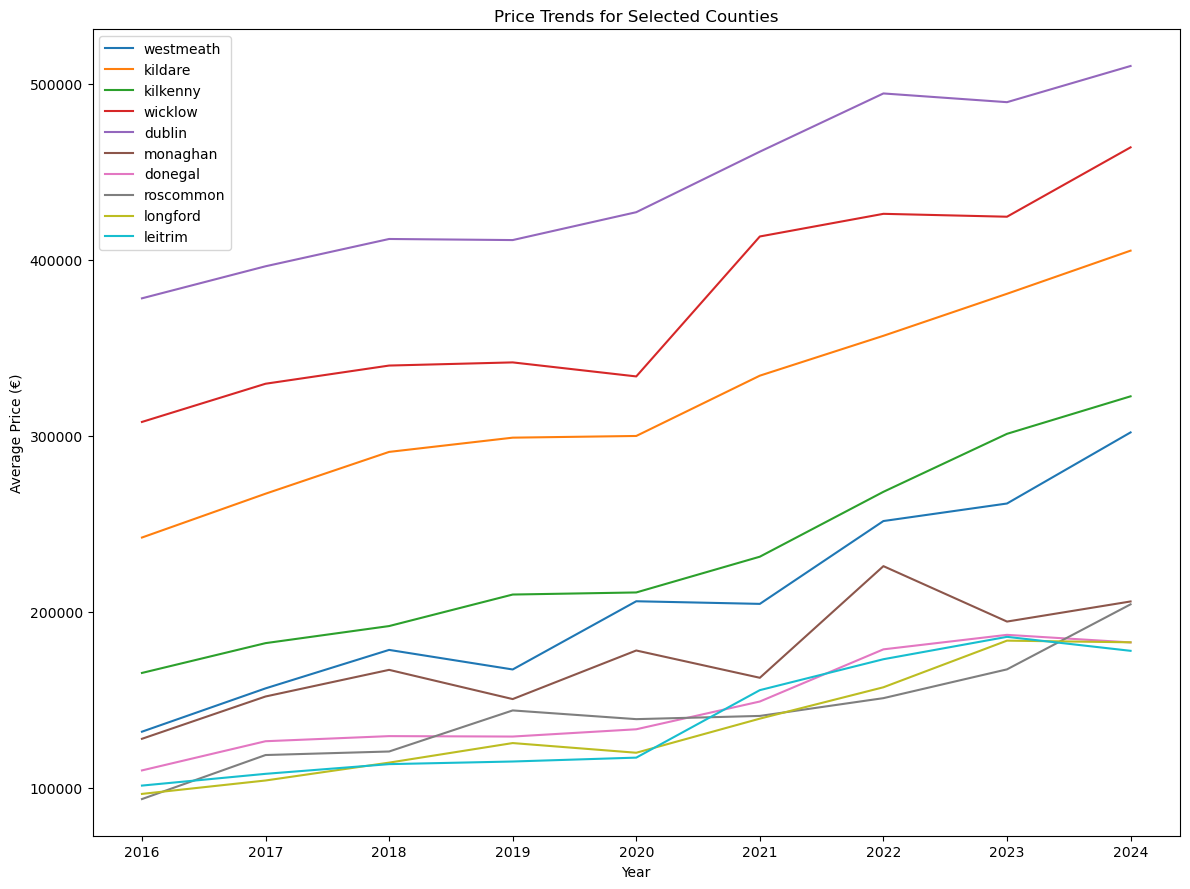

In [250]:
plt.figure(figsize=(12, 9))  # make it wider

top5 = sorted(county_trends.items(), key=lambda x: x[1], reverse=True)[:5]
bottom5 = sorted(county_trends.items(), key=lambda x: x[1])[:5]

selected = [c[0] for c in top5 + bottom5]

for county in selected:
    df[df['county'] == county].groupby('year')['price'].mean().plot(label=county)

plt.legend()
plt.title('Price Trends for Selected Counties')
plt.xlabel('Year')
plt.ylabel('Average Price (€)')

plt.tight_layout()
plt.show()

This shows the growth trends of the top 5 fastest growing and 5 slowest growing counties, allowing us to visually compare their trajectories over time. 

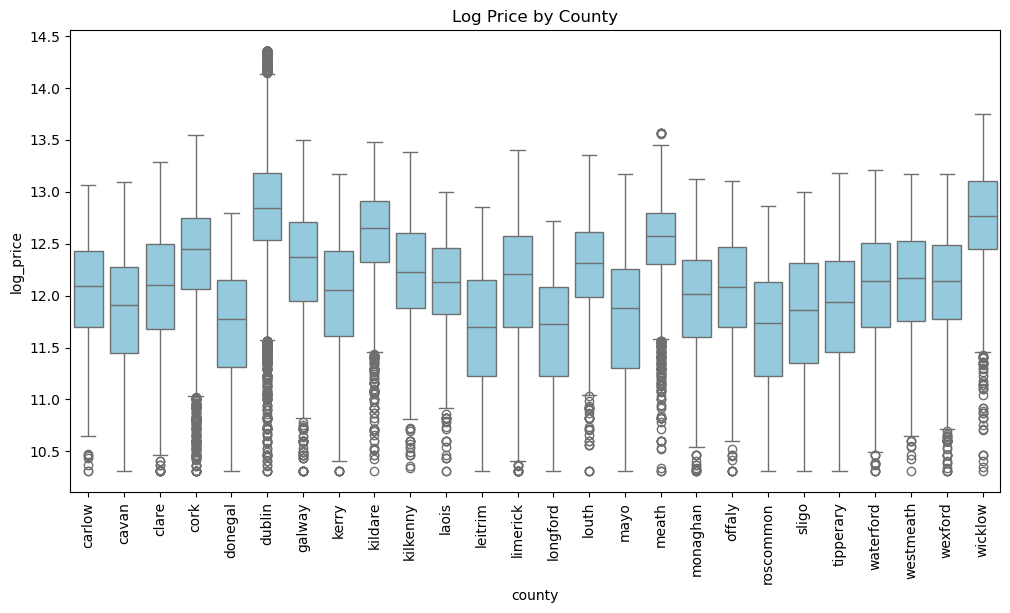

In [251]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x='county', y='log_price', data=df, color='skyblue')
plt.xticks(rotation=90)
plt.title('Log Price by County')
plt.show()

The box plots are centred around the median value, with the top and bottom extends of the boxes reflecting the 75th and 25th percentiles, respectively. The whiskers extend to values within 1.5 times the interquartile range, and points beyond this range are plotted as outliers. Dublin has a noticeable collection of high-price outliers.

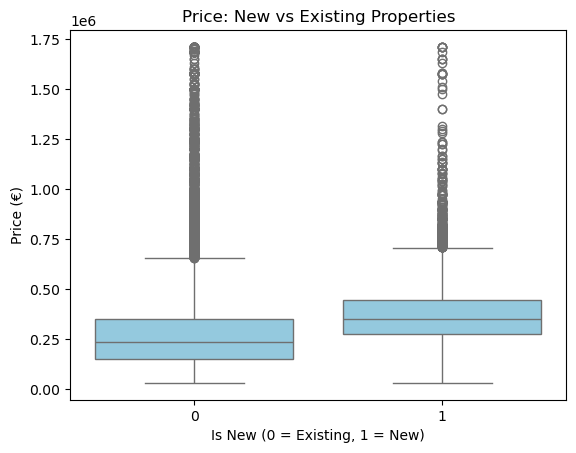

In [252]:
sns.boxplot(x='is_new', y='price', data=df, color='skyblue')
plt.title('Price: New vs Existing Properties')
plt.ylabel('Price (€)')
plt.xlabel('Is New (0 = Existing, 1 = New)')
plt.show()

Once again, box plots are centred around the median value, with the top and bottom extends of the boxes reflecting the 75th and 25th percentiles, respectively. For new properties, the values within these percentiles are noticeably higher than for non-new properties. However, outliers above the normal range are more clustered towards just outside of the top whisker.

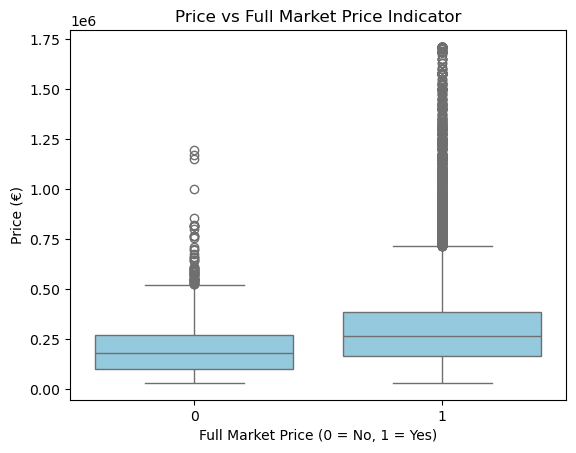

In [253]:
sns.boxplot(x='is_full_market_price', y='price', data=df, color='skyblue')
plt.title('Price vs Full Market Price Indicator')
plt.xlabel('Full Market Price (0 = No, 1 = Yes)')
plt.ylabel('Price (€)')
plt.show()

The full-price properties had higher median the non-full-price properties, with far more high-price outliers as well.

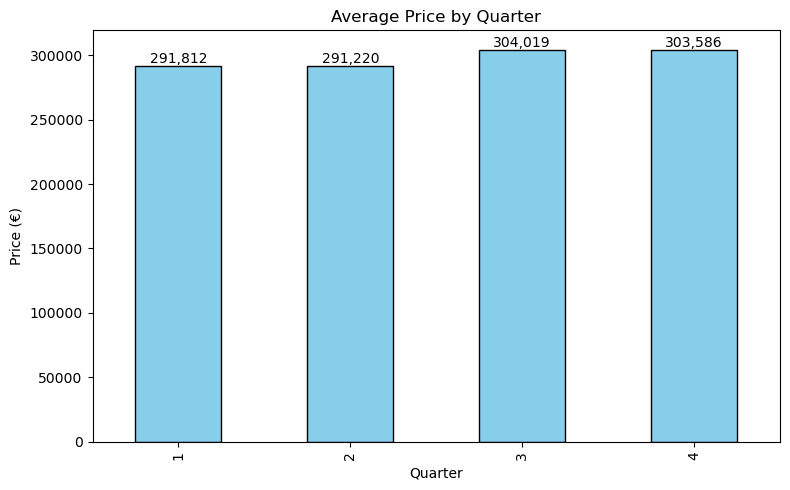

In [254]:
avg_price_quarter = df.groupby('quarter')['price'].mean()

ax = avg_price_quarter.plot(kind='bar', figsize=(8,5), color='skyblue', edgecolor='black')

plt.title('Average Price by Quarter')
plt.ylabel('Price (€)')
plt.xlabel('Quarter')

# Add labels on top of bars
for i, v in enumerate(avg_price_quarter):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The average prices were higher in the latter two quarters compared to the first two, with a minute decrease from the first to the second and from the third to the fourth. 

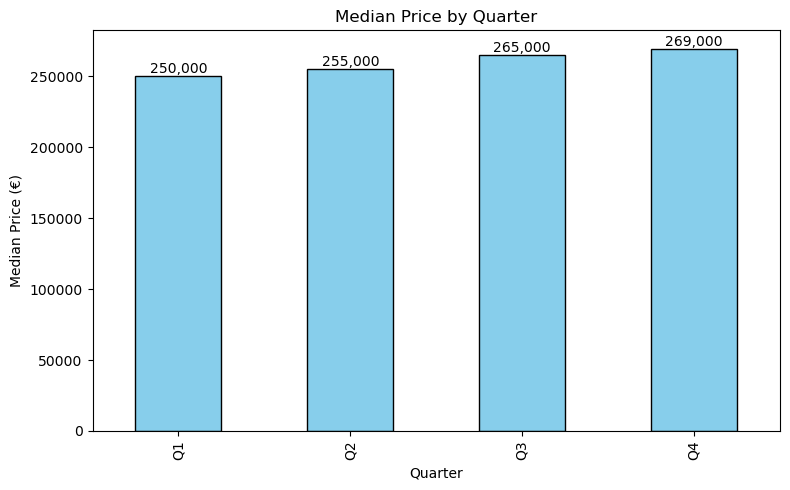

In [255]:
median_price_quarter = df.groupby('quarter')['price'].median()

ax = median_price_quarter.plot(kind='bar', figsize=(8,5), color='skyblue', edgecolor='black')

plt.title('Median Price by Quarter')
plt.ylabel('Median Price (€)')
plt.xlabel('Quarter')

# Add labels on bars
for i, v in enumerate(median_price_quarter):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

# Optional: nicer labels
ax.set_xticklabels(['Q1','Q2','Q3','Q4'])

plt.tight_layout()
plt.show()

Unlike the average price per quarter, the median price per quarter shows a slight increase from one quarter to the next.

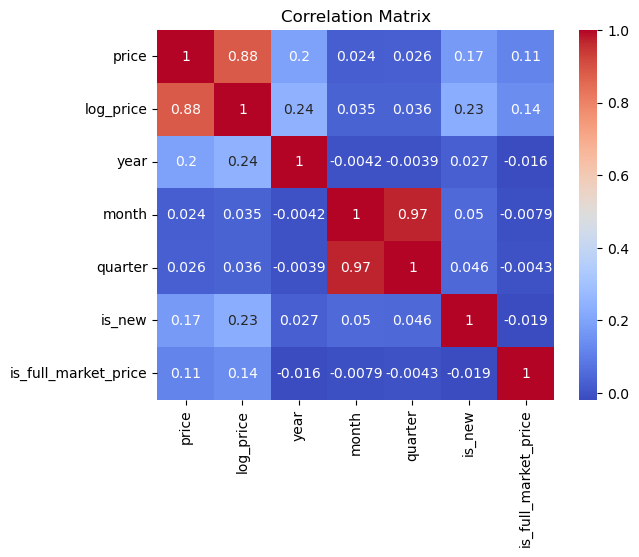

In [256]:
corr = df[['price','log_price','year','month','quarter','is_new','is_full_market_price']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows a high correlation between month and quarter and between price and log price. 

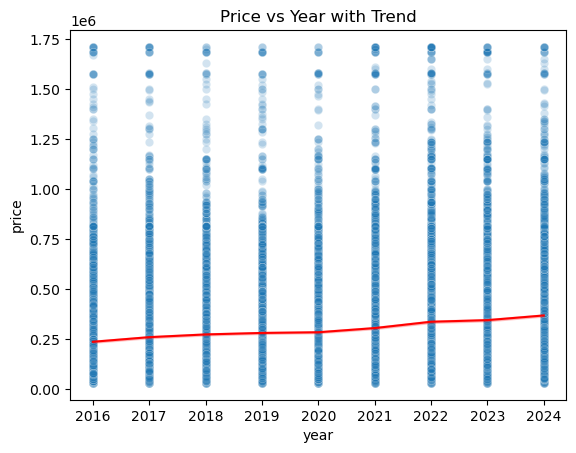

In [257]:
import seaborn as sns

sns.scatterplot(x='year', y='price', data=df, alpha=0.2)
sns.lineplot(x='year', y='price', data=df, estimator='mean', color='red')
plt.title('Price vs Year with Trend')
plt.show()

This plot shows that many of the high price outliers were somewhat stable, while prices in general gradually increased.

New properties had a higher median price vs. non-new properties.

A brief analysis of the data features reveals that the average price rose 55.88% and the median price rose 79.89 % between 2016 and 2024, not injusted for inflation. The data shows that average and median prices were higher during the second half of the year than the first, with median prices increasing each quarter. The log price box plots for each county showed some very similar values between Dublin and Wicklow, but with Dublin having more high-price outliers. Prices were higher for new properties than for existing properties, and full-price properties had higher prices than non-full-price properties. 




# Part 4: Feature Engineering

In [258]:
import pandas as pd
import numpy as np

# Load cleaned dataset
df = pd.read_csv("ppr_group_25275889_train_cleaned_final.csv")

# CPI data Ireland
cpi_data = pd.DataFrame({
    'year': [
        2010, 2011, 2012, 2013, 2014,
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2023, 2024, 2025
    ],
    'inflation_index': [
        92.1, 93.5, 94.0, 94.7, 95.8,
        100.0, 100.5, 100.8, 101.3, 102.0,
        102.5, 105.0, 112.0, 118.5, 121.0, 123.0
    ]
})

df = df.merge(cpi_data, on='year', how='left')

df['inflation_index'] = df['inflation_index'].astype('float64')

# Adjust price to 2025 euros
base_cpi = cpi_data[cpi_data['year'] == 2025]['inflation_index'].values[0]
df['price_adjusted'] = df['price'] * (base_cpi / df['inflation_index'])
df['price_adjusted'] = df['price_adjusted'].astype('float64')



# Approx CSO population by county
population_data = pd.DataFrame({
    'county': [
        'dublin', 'cork', 'galway', 'limerick', 'kildare',
        'meath', 'wicklow', 'waterford', 'clare', 'mayo'
    ],
    'population': [
        1450000, 580000, 270000, 205000, 245000,
        220000, 155000, 125000, 120000, 130000
    ]
})

# Merge into dataset
df = df.merge(population_data, on='county', how='left')

df['population'] = df['population'].fillna(df['population'].median())

df['population'] = df['population'].astype('float64')


# Save the dataset
df.to_csv("ppr-group-25275889-train-engineered.csv", index=False)

**Added Features**

Inflation was incorporated using Consumer Price Index (CPI) data. A new feature, Inflation_Index, was added, and property prices were adjusted to real terms (Price_Adjusted) using a 2025 baseline. This ensures comparability across years and prevents the model from learning misleading patterns driven by inflation rather than true property value changes. Additionally, a  Population feature was added from the CSO database by county. This also helps train the model to predict property values based on higher population counties such as Dublin, having more expensive properties. 
Central Statistics Office (CSO) (2026) Consumer Price Index (CPI). Available at: https://data.gov.ie/dataset/cpm01-consumer-price-index (Accessed: 29 March 2026).

Added features: 

area_code - Float64

inflation_index - Float64

population - Float64

In [259]:
df.dtypes

county                      str
price                   float64
is_full_market_price      int64
month                     int64
quarter                   int64
year                      int64
area_code                   str
log_price               float64
is_new                    int64
inflation_index         float64
price_adjusted          float64
population              float64
dtype: object

bruelieoirhnôiezr

# Loading test data 

In [260]:
try: 
    df_test_data = pd.read_csv("ppr-group-25275889-test.csv", 
                     keep_default_na=True, 
                     delimiter=',', 
                     skipinitialspace=True)
    
    print(f"✓ Successfully loaded dataset with {df_test_data.shape[0]} rows and {df_test_data.shape[1]} columns")
    
    display(df_test_data.head(3))

except FileNotFoundError:
    print("The file ppr-group-25275889-test.csv was not found in the current directory")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

✓ Successfully loaded dataset with 10000 rows and 9 columns


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,08/12/2025,"7 Alder Way, Ard Griffin, Waterrock",Cork,NaN,"€356,828.19",No,Yes,New Dwelling house /Apartment,NaN
1,04/03/2025,"3 MONASTERY CRESCENT, CLONDALKIN, DUBLIN 22",Dublin,D22NA71,"€440,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
2,24/03/2025,"35 COILLTE MHUIRLINNE, BALLYBANE, GALWAY",Galway,H91KWK2,"€340,100.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [261]:
# Standardise column names 
df_test_data.columns = df_test_data.columns.str.lower().str.replace(r'\(dd/mm/yyyy\)', ' ', regex=True).str.replace("(€)", " ").str.strip().str.replace(" ", "_")

In [262]:
print("Column names are:")
for col in df_test_data.columns:
    print(f"{col}")

Column names are:
date_of_sale
address
county
eircode
price
not_full_market_price
vat_exclusive
description_of_property
property_size_description


In [263]:
# Stripping away non-numeric from price cells
df_test_data["price"] = (df_test_data["price"]
                   .str.replace("€", "", regex=False)
                   .str.replace(",", "", regex=False)
                   .str.strip())

# Converting Price column from categorical to continuous
df_test_data["price"] = df_test_data["price"].astype("float64")

In [264]:
# Convert all object columns to categorical
for col in df_test_data.select_dtypes('object').columns:
    df_test_data[col] = df_test_data[col].astype('category')

/var/folders/sf/cpst0jxn09170tcq8lkwcsjr0000gn/T/ipykernel_22242/1307532421.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_test_data.select_dtypes('object').columns:


In [265]:
# Update column groups after type corrections
numeric_columns = df_test_data.select_dtypes(['int64', 'float64']).columns
category_columns = df_test_data.select_dtypes('category').columns

print("✓ Data types corrected:")
print(f"  - Numeric features: {len(numeric_columns)}")
for col in numeric_columns:
    print(f"        {col}")
print()
print(f"  - Categorical features: {len(category_columns)}")
for col in category_columns:
    print(f"        {col}")

✓ Data types corrected:
  - Numeric features: 2
        price
        property_size_description

  - Categorical features: 7
        date_of_sale
        address
        county
        eircode
        not_full_market_price
        vat_exclusive
        description_of_property


In [266]:
# Standardise all values from all category columns to lowercase
for col in category_columns:
    df_test_data[col] = df_test_data[col].str.lower().str.strip()

In [267]:
# standardised address values 

to_replace = {r"\broad\b": "rd",
    r"\bstreet\b": "st",
    r"\bavenue\b": "ave",
    r"\bboulevard\b": "blvd",
    r"\bdrive\b": "dr",
    r"\bcourt\b": "ct",
    r"\blane\b": "la",
    r"\bpark\b": "prk",
    r"\bterrace\b": "ter",
    r"\bplace\b": "pl",
    r"\bsquare\b": "sq",
    r"\bapartment\b": "apt",
    r"\bapartments\b": "apts",
    r"\bco\b": "",
    r"\bcounty\b": "",
    r"\.": "",
    r",": ""
}

In [268]:
# Replacing them in address column
df_test_data["address"] = df_test_data["address"].replace(to_replace, regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
print("Standardisation of address values completed")

Standardisation of address values completed


In [269]:
print("Dataset Validation Checks:")
print("="*60)

# Check 1: Dataset is not empty
if df_test_data.empty:
    print("⚠ WARNING: Dataset is empty!")
else:
    print(f"✓ Dataset contains {df_test_data.shape[0]:,} rows")

# Check 2: Check for duplicate rows
duplicate_count = df_test_data.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠ WARNING: Found {duplicate_count} duplicate rows")
else:
    print("✓ No duplicate rows found")

# Check 3: Check if all columns are unnamed
unnamed_cols = [col for col in df_test_data.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    print(f"⚠ WARNING: Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")
else:
    print("✓ All columns have names")

# Check 4: Check for duplicates columns
df_test_dataT = df_test_data.T
print(f"Number of duplicate columns is: {df_test_dataT.duplicated().sum()}")

Dataset Validation Checks:
✓ Dataset contains 10,000 rows
✓ No duplicate rows found
✓ All columns have names
Number of duplicate columns is: 0


In [270]:
df_test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date_of_sale               10000 non-null  object 
 1   address                    10000 non-null  object 
 2   county                     10000 non-null  object 
 3   eircode                    7382 non-null   object 
 4   price                      10000 non-null  float64
 5   not_full_market_price      10000 non-null  object 
 6   vat_exclusive              10000 non-null  object 
 7   description_of_property    10000 non-null  object 
 8   property_size_description  0 non-null      float64
dtypes: float64(2), object(7)
memory usage: 703.3+ KB


**Duplicate checks** 

In [271]:
# Identifying duplicates, where all columns in rows match
true_duplicate_rows = df_test_data[df_test_data.duplicated()]

In [272]:
# Dropping "true" duplicates
df_test_data = df_test_data.drop_duplicates(true_duplicate_rows)
print("Dropped duplicates from the Dataframe")

Dropped duplicates from the Dataframe


In [273]:
numeric_columns = df_test_data.select_dtypes(['int64', 'float64']).columns
category_columns = df_test_data.select_dtypes('category').columns

Start from here

In [274]:
if "is_full_market_price" not in df_test_data.columns:
    df_test_data["is_full_market_price"] = df_test_data["not_full_market_price"].str.lower().map({'no': 1, 'yes': 0}).astype(int)  
    df_test_data["is_full_market_price"] = df_test_data["is_full_market_price"].astype("category")  
    print("Column 'is_full_market_price' successfully changed")
else:
    print("Column 'is_full_market_price' already changed")

Column 'is_full_market_price' successfully changed


In [275]:
if "not_full_market_price" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="not_full_market_price")
    print("Column 'not_full_market_price' successfully dropped")
else:
    print("Column 'not_full_market_price' already dropped")

Column 'not_full_market_price' successfully dropped


In [276]:
df_test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   date_of_sale               10000 non-null  object  
 1   address                    10000 non-null  object  
 2   county                     10000 non-null  object  
 3   eircode                    7382 non-null   object  
 4   price                      10000 non-null  float64 
 5   vat_exclusive              10000 non-null  object  
 6   description_of_property    10000 non-null  object  
 7   property_size_description  0 non-null      float64 
 8   is_full_market_price       10000 non-null  category
dtypes: category(1), float64(2), object(6)
memory usage: 634.9+ KB


In [277]:
if 'date_of_sale' in df_test_data.columns:

    # converting date of sale to a datetime object
    df_test_data["date_of_sale"] = pd.to_datetime(df_test_data["date_of_sale"], dayfirst=True)
    print("Column 'date of sale' has been successfully converted")

    # converting month and quarter to categorical features
    df_test_data['month'] = df_test_data['date_of_sale'].dt.month.astype('category')
    print("Column 'month' has been successfully created")

    df_test_data['quarter'] = df_test_data["date_of_sale"].dt.quarter.astype('category')
    print("Column 'quarter' has been successfully created")

    # converting year to a numeric feature
    df_test_data['year'] = df_test_data["date_of_sale"].dt.year
    print("Column 'year' has been successfully created")

    # dropping date of sale column
    df_test_data = df_test_data.drop(columns=['date_of_sale'])
    print("Column 'date_of_sale' successfully dropped.")
else:
    print("New features already created and 'date of sale' column already dropped.")

Column 'date of sale' has been successfully converted
Column 'month' has been successfully created
Column 'quarter' has been successfully created
Column 'year' has been successfully created
Column 'date_of_sale' successfully dropped.


In [278]:
town_to_key = {
    ('youghal', 'cork'): 'p36',
    ('wicklow', 'wicklow'): 'a67',
    ('whitechurch', 'cork'): 't34',
    ('wexford', 'wexford'): 'y35',
    ('westport', 'mayo'): 'f28',
    ('watergrasshill', 'cork'): 't56',
    ('waterford', 'waterford'): 'x91',
    ('virginia', 'cavan'): 'a82',
    ('tullamore', 'offaly'): 'r35',
    ('tuam', 'galway'): 'h54',
    ('tralee', 'kerry'): 'v92',
    ('tipperary', 'tipperary'): 'e34',
    ('thurles', 'tipperary'): 'e41',
    ('swords', 'dublin'): 'k67',
    ('dublin airport', 'dublin'): 'k67',
    ('summerhill', 'meath'): 'a83',
    ('sligo', 'sligo'): 'f91',
    ('skibbereen', 'cork'): 'p81',
    ('skerries', 'dublin'): 'k34',
    ('shannon', 'clare'): 'v14',
    ('rush', 'dublin'): 'k56',
    ('roscrea', 'tipperary'): 'e53',
    ('roscommon', 'roscommon'): 'f42',
    ('ratoath', 'meath'): 'a85',
    ('rathnew', 'wicklow'): 'a67',
    ('portlaoise', 'laois'): 'r32',
    ('oldtown', 'dublin'): 'a45',
    ('newtownmountkennedy', 'wicklow'): 'a63',
    ('newcastle west', 'limerick'): 'v42',
    ('newcastle', 'wicklow'): 'a63',
    ('newbridge', 'kildare'): 'w12',
    ('new ross', 'wexford'): 'y34',
    ('nenagh', 'tipperary'): 'e45',
    ('navan', 'meath'): 'c15',
    ('naas', 'kildare'): 'w91',
    ('mullingar', 'westmeath'): 'n91',
    ('muine bheag', 'carlow'): 'r21',
    ('monkstown', 'dublin'): 'a94',
    ('monasterevin', 'kildare'): 'w34',
    ('monaghan', 'monaghan'): 'h18',
    ('mitchelstown', 'cork'): 'p67',
    ('midleton', 'cork'): 'p25',
    ('maynooth', 'kildare'): 'w23',
    ('mallow', 'cork'): 'p51',
    ('malahide', 'dublin'): 'k36',
    ('macroom', 'cork'): 'p12',
    ('lusk', 'dublin'): 'k45',
    ('lucan', 'dublin'): 'k78',
    ('loughrea', 'galway'): 'h62',
    ('longford', 'longford'): 'n39',
    ('little island', 'cork'): 't45',
    ('listowel', 'kerry'): 'v31',
    ('limerick', 'limerick'): 'v94',
    ('lifford', 'donegal'): 'f93',
    ('letterkenny', 'donegal'): 'f92',
    ('laytown', 'meath'): 'a92',
    ('bettystown', 'meath'): 'a92',
    ('mornington', 'meath'): 'a92',
    ('kinsale', 'cork'): 'p17',
    ('kingscourt', 'cavan'): 'a82',
    ('kilrush', 'clare'): 'v15',
    ('kilmallock', 'limerick'): 'v35',
    ('kilmacthomas', 'waterford'): 'x42',
    ('killarney', 'kerry'): 'v93',
    ('kilkenny', 'kilkenny'): 'r95',
    ('kildare', 'kildare'): 'r51',
    ('kilcoole', 'wicklow'): 'a63',
    ('kells', 'meath'): 'a82',
    ('greystones', 'wicklow'): 'a63',
    ('gorey', 'wexford'): 'y25',
    ('glenageary', 'dublin'): 'a96',
    ('garristown', 'dublin'): 'a42',
    ('galway', 'galway'): 'h91',
    ('fermoy', 'cork'): 'p61',
    ('enniscorthy', 'wexford'): 'y21',
    ('ennis', 'clare'): 'v95',
    ('enfield', 'meath'): 'a83',
    ('edenderry', 'offaly'): 'r45',
    ('dunshaughlin', 'meath'): 'a85',
    ('dunmanway', 'cork'): 'p47',
    ('dungarvan', 'waterford'): 'x35',
    ('dundalk', 'louth'): 'a91',
    ('dunboyne', 'meath'): 'a86',
    ('drogheda', 'louth'): 'a92',
    ('donoughmore', 'cork'): 'p32',
    ('donegal', 'donegal'): 'f94',
    ('delgany', 'wicklow'): 'a63',
    ('curragh camp', 'kildare'): 'r56',
    ('crookstown', 'cork'): 'p14',
    ('cootehill', 'cavan'): 'h16',
    ('cobh', 'cork'): 'p24',
    ('clonmel', 'tipperary'): 'e91',
    ('clones', 'monaghan'): 'h23',
    ('clonakilty', 'cork'): 'p85',
    ('clifden', 'galway'): 'h71',
    ('claremorris', 'mayo'): 'f12',
    ('charleville', 'cork'): 'p56',
    ('cavan', 'cavan'): 'h12',
    ('castlerea', 'roscommon'): 'f45',
    ('castleblaney', 'monaghan'): 'a75',
    ('castlebar', 'mayo'): 'f23',
    ('cashel', 'tipperary'): 'e25',
    ('carrigaline', 'cork'): 'p43',
    ('carrickmacross', 'monaghan'): 'a81',
    ('carrick-on-suir', 'tipperary'): 'e32',
    ('carrick-on-shannon', 'leitrim'): 'n41',
    ('carlow', 'carlow'): 'r93',
    ('cahir', 'tipperary'): 'e21',
    ('caherciveen', 'kerry'): 'v23',
    ('bray', 'wicklow'): 'a98',
    ('boyle', 'roscommon'): 'f52',
    ('booterstown', 'dublin'): 'a94',
    ('blackrock', 'dublin'): 'a94',
    ('birr', 'offaly'): 'r42',
    ('belturbet', 'cavan'): 'h14',
    ('bantry', 'cork'): 'p75',
    ('bandon', 'cork'): 'p72',
    ('ballymote', 'sligo'): 'f56',
    ('ballyhaunis', 'mayo'): 'f35',
    ('ballyboughal', 'dublin'): 'a41',
    ('ballybay', 'monaghan'): 'a75',
    ('ballinrobe', 'mayo'): 'f31',
    ('ballincollig', 'cork'): 'p31',
    ('ballinasloe', 'galway'): 'h53',
    ('ballina', 'mayo'): 'f26',
    ('balbriggan', 'dublin'): 'k32',
    ('athy', 'kildare'): 'r14',
    ('athlone', 'westmeath'): 'n37',
    ('athenry', 'galway'): 'h65',
    ('ashbourne', 'meath'): 'a84',
    ('arklow', 'wicklow'): 'y14',
    ('ardee', 'louth'): 'a92',
    ('blackrock', 'dublin'): 'a94',
    ('monkstown', 'dublin'): 'a94',
    ('booterstown', 'dublin'): 'a94',
    ('dalkey', 'dublin'): 'a96',
    ('killiney', 'dublin'): 'a96',
    ('sandycove', 'dublin'): 'a96',
    ('clontarf', 'dublin'): 'd03',
    ('ballsbridge', 'dublin'): 'd04',
    ('donnybrook', 'dublin'): 'd04',
    ('rathmines', 'dublin'): 'd06',
    ('ranelagh', 'dublin'): 'd06',
    ('phibsborough', 'dublin'): 'd07',
    ('smithfield', 'dublin'): 'd07',
    ('stoneybatter', 'dublin'): 'd07',
    ('ballyfermot', 'dublin'): 'd10',
    ('finglas', 'dublin'): 'd11',
    ('castleknock', 'dublin'): 'd15',
    ('dundrum', 'dublin'): 'd14',
    ('goatstown', 'dublin'): 'd14',
    ('sutton', 'dublin'): 'd13',
    ('howth', 'dublin'): 'd13',
    ('portmarnock', 'dublin'): 'd13',
    ('douglas', 'cork'): 't12',
    ('rochestown', 'cork'): 't12',
    ('ballinlough', 'cork'): 't12',
    ('blackpool', 'cork'): 't23',
    ('ballyvolane', 'cork'): 't23',
    ('glanmire', 'cork'): 't45',
    ('cloyne', 'cork'): 'p25',
    ('celbridge', 'kildare'): 'w23',
    ('leixlip', 'kildare'): 'w23',
    ('kilcock', 'kildare'): 'w23',
    ('kildare town', 'kildare'): 'r51',
    ('sallins', 'kildare'): 'w91',
    ('clane', 'kildare'): 'w91',
    ('trim', 'meath'): 'c15',
    ('oldcastle', 'meath'): 'a82',
    ('stamullen', 'meath'): 'k32',
    ('kenmare', 'kerry'): 'v93',
    ('castleisland', 'kerry'): 'v92',
    ('killorglin', 'kerry'): 'v93',
    ('dingle', 'kerry'): 'v92',
    ('shannon', 'clare'): 'v14',
    ('ennis', 'clare'): 'v95',
    ('kilrush', 'clare'): 'v15',
    ('sixmilebridge', 'clare'): 'v95',
    ('killaloe', 'clare'): 'v94',
    ('castletroy', 'limerick'): 'v94',
    ('raheen', 'limerick'): 'v94',
    ('dooradoyle', 'limerick'): 'v94',
    ('adare', 'limerick'): 'v94',
    ('abbeyfeale', 'limerick'): 'v94',
    ('newcastle west', 'limerick'): 'v42'
}

In [279]:

df_test_data["area_code"] = ''

def infer_area_codes(row):
    # Prioritize Eircode if it exists
    if pd.notnull(row['eircode']) and len(str(row['eircode'])) >= 3:
        return str(row['eircode'])[:3].strip()
    
    addr = str(row['address']).lower()
    cty = str(row['county']).lower()
    
    # Check for dublin first 
    dub_match = re.search(r'dublin (\d+|6w)', addr)
    if dub_match:
        val = dub_match.group(1)
        return f"d{val.zfill(2)}" if val != '6w' else 'd6w'
    
    # Then check in the dictionary
    for (town, county), key in town_to_key.items():
        if town in addr and county == cty:
            return key
            
    return "gen_" + cty

# Run the function
df_test_data['area_code'] = df_test_data.apply(infer_area_codes, axis=1)

total = len(df_test_data)
unknown_count = df_test_data['area_code'].str.contains('gen').sum()
success_count = total - unknown_count

print(f"Total Rows: {total}")
print(f"Successfully Mapped to a Key: {success_count} ({ (success_count/total)*100:.2f}%)")
print(f"Mapped to General County: {unknown_count} ({ (unknown_count/total)*100:.2f}%)")

if unknown_count > 0:
    print("\nCounties with most 'General' mappings (would need more town entries):")
    print(df_test_data[df_test_data['area_code'].str.contains('gen')]['county'].value_counts().head(5))

Total Rows: 10000
Successfully Mapped to a Key: 8798 (87.98%)
Mapped to General County: 1202 (12.02%)

Counties with most 'General' mappings (would need more town entries):
county
dublin     344
cork       222
kildare     65
wicklow     59
galway      54
Name: count, dtype: int64


In [280]:
# Running function to compare Eircode with guesses

test_df = df_test_data[df_test_data['eircode'].notna()].copy()


def test_inference(row):
    addr = str(row['address']).lower()
    cty = str(row['county']).lower()
    # Ignore Eircodes 
    
    # Regex Dublin
    dub_match = re.search(r'dublin (\d+|6w)', addr)
    if dub_match:
        val = dub_match.group(1)
        return f"d{val.zfill(2)}" if val != '6w' else 'd6w'
    
    # Check in dictionary
    for (town, county), key in town_to_key.items():
        if town in addr and county == cty:
            return key
            
    return "gen_" + cty

# Run test
test_df['blind_guess'] = test_df.apply(test_inference, axis=1)
test_df['actual_code'] = test_df['eircode'].str.strip().str[:3]

matches = (test_df['blind_guess'] == test_df['actual_code']).sum()
accuracy = (matches / len(test_df)) * 100

print(f"When forced to guess without an Eircode, the code was correct {accuracy:.2f}% of the time.")

# Comparing mapping of eircodes to fallback on county
print("\nBreakdown of results:")
print(test_df['blind_guess'].str.contains('gen').value_counts().rename({True: 'Failed (Returned GEN)', False: 'Attempted a Mapping'}))

When forced to guess without an Eircode, the code was correct 64.67% of the time.

Breakdown of results:
blind_guess
Attempted a Mapping      5561
Failed (Returned GEN)    1821
Name: count, dtype: int64


In [281]:
# Filter for rows where the code tried to guess but got it wrong
hard_errors = test_df[(test_df['blind_guess'] != test_df['actual_code']) & 
                      (~test_df['blind_guess'].str.contains('gen'))]

print(f"Hard Errors (Wrong Guess): {len(hard_errors)}")
print(f"Soft Errors (Gave up/GEN): {len(test_df[test_df['blind_guess'].str.contains('gen')])}")

pctg_hard_errors = (len(hard_errors)/len(test_df)) * 100
print(f"\nOut of {len(test_df)} possible mappings, the code tried to map and failed on {pctg_hard_errors.__round__(2)}% of guesses")

# See the top hard errors to find dictionary overlaps
print("\nTop 10 Dictionary Hard Errors:")
print(hard_errors[['address', 'actual_code', 'blind_guess']].head(10))
print("="*80)

Hard Errors (Wrong Guess): 787
Soft Errors (Gave up/GEN): 1821

Out of 7382 possible mappings, the code tried to map and failed on 10.66% of guesses

Top 10 Dictionary Hard Errors:
                                              address actual_code blind_guess
14                        1 glentoskert malin donegal         f93         f94
26              100 charlesland ct greystones wicklow         a63         a67
27         63 the sq hazelhatch prk celbridge kildare         w23         r51
37                 18 shanavine way clonmel tipperary         e91         e34
38                     10 dunlo ct ballinasloe galway         h53         h91
40                           drumgart belturbet cavan         h14         h12
42  208a coille bheithe st conlons rd nenagh tippe...         e45         e34
63                     30 cluain dara leixlip kildare         w23         r51
66                 16 knockroe ct castlerea roscommon         f45         f42
73                       30 churchfield

In [282]:
# Changing area_code data type from object to categorical
df_test_data["area_code"] = df_test_data["area_code"].astype('category') 

In [283]:
if "eircode" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="eircode")
    print("Column 'eircode' successfully dropped")
else:
    print("Column 'eircode' already dropped")

Column 'eircode' successfully dropped


In [284]:
if "address" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="address")
    print("Column 'address' successfully dropped")
else:
    print("Column 'address' already dropped")

Column 'address' successfully dropped


In [285]:
rows_to_update = df_test_data[df_test_data["vat_exclusive"] == "yes"].shape[0]
if rows_to_update > 0:
    df_test_data.loc[df_test_data["vat_exclusive"] == "yes", "price"] *= 1.135

In [286]:
if "vat_exclusive" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="vat_exclusive")
    print("Column 'vat_exclusive' successfully dropped")
else:
    print("Column 'vat_exclusive' already dropped")

Column 'vat_exclusive' successfully dropped


In [287]:
log_price = np.log(df_test_data["price"])

In [288]:
price = df_test_data["price"]

In [289]:
# dropping rows that are above 10 Million
upper_limit = 10000000
above_10_M = price > int(upper_limit)
number_above_10_M = above_10_M.sum()
number_above_10_M

rows_to_drop = df_test_data[above_10_M].index
if number_above_10_M > 0:
    print(f"Dropping {len(rows_to_drop)} row(s):")
    print(f"  Indices: {list(rows_to_drop)}")
    df_test_data = df_test_data.drop(rows_to_drop)
else:
    print("Builds above 10 Million have already been dropped")

Dropping 14 row(s):
  Indices: [112, 1856, 1909, 2090, 2375, 2936, 3200, 3589, 4650, 5018, 6640, 7612, 9132, 9977]


In [290]:
# dropping rows that are below 30K
lower_limit = 30000
below_30k = price < int(lower_limit)
number_below_30k = below_30k.sum()
number_below_30k

rows_to_drop = df_test_data[below_30k].index
if number_below_30k > 0:
    print(f"Dropping {len(rows_to_drop)} row(s):")
    print(f"  Indices: {list(rows_to_drop)}")
    df_test_data = df_test_data.drop(rows_to_drop)
else:
    print("Builds below 30 Thousand have already been dropped")

Dropping 51 row(s):
  Indices: [20, 38, 515, 586, 659, 812, 822, 1354, 1369, 1976, 2129, 3002, 3330, 3356, 3439, 3474, 3730, 3858, 3875, 4006, 4168, 4250, 4551, 4599, 4941, 5065, 5097, 5187, 5388, 5546, 5748, 6303, 6317, 6949, 7126, 7144, 7249, 7343, 7683, 7781, 7925, 7927, 8032, 8217, 8285, 8426, 8541, 8587, 8655, 9780, 9970]


/var/folders/sf/cpst0jxn09170tcq8lkwcsjr0000gn/T/ipykernel_22242/431986378.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rows_to_drop = df_test_data[below_30k].index


In [291]:
# reverting all area codes less than 30 to their original county
area_code_counts = df_test_data["area_code"].value_counts()

threshold = 30

unreliable_codes = area_code_counts[area_code_counts < threshold].index

mask = df_test_data["area_code"].isin(unreliable_codes)
df_test_data.loc[mask, "area_code"] = "gen_" + df_test_data["county"].str.replace(" ", "")

print("Reverted", mask.sum(), "rows back to their original county")

Reverted 1060 rows back to their original county


In [292]:
# UPPER OUTLIERS
df_test_data['regional_clamp'] = df_test_data.groupby('area_code')['price'].transform(lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))


df_test_data['price'] = np.where(
    df_test_data['price'] > df_test_data['regional_clamp'], 
    df_test_data['regional_clamp'], 
    df_test_data['price']
)

# count how many values were actually clamped
clamped_count = (df_test_data['price'] == df_test_data['regional_clamp']).sum()
print(f"Successfully clamped {clamped_count} outliers.")

# remove the regional_clamp column 
df_test_data = df_test_data.drop(columns=['regional_clamp'])

Successfully clamped 430 outliers.


In [293]:
# LOWER OUTLIERS
df_test_data['regional_clamp'] = df_test_data.groupby('area_code')['price'].transform(lambda x: x.quantile(0.25) - 1.5 * (x.quantile(0.75) - x.quantile(0.25)))


df_test_data['price'] = np.where(
    df_test_data['price'] < df_test_data['regional_clamp'], 
    df_test_data['regional_clamp'], 
    df_test_data['price']
)

# count how many values were actually clamped
clamped_count = (df_test_data['price'] == df_test_data['regional_clamp']).sum()
print(f"Successfully clamped {clamped_count} outliers.")

# remove the regional_clamp column 
df_test_data = df_test_data.drop(columns=['regional_clamp'])

Successfully clamped 78 outliers.


In [294]:
if "log_price" not in df_test_data.columns:
    df_test_data["log_price"] = np.log(df_test_data["price"])
    print("Column 'log_price' successfully created")
else:
    print("Column 'log_price' already created")

Column 'log_price' successfully created


In [295]:
irish = (df_test_data["description_of_property"] != "second-hand dwelling house /apartment") & (df_test_data["description_of_property"] != "new dwelling house /apartment")

df_test_data.loc[irish, "description_of_property"] = "second-hand dwelling house /apartment"

In [296]:
if "is_new" not in df_test_data.columns:
    df_test_data["is_new"] = df_test_data["description_of_property"].str.lower().str.startswith("new", na=False).astype(int)
    df_test_data["is_new"] = df_test_data["is_new"].astype("category")
    print("Column 'is_new' successfully created")
else:
    print("Column 'is_new' already created")

Column 'is_new' successfully created


In [297]:
if "description_of_property" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="description_of_property")
    print("Column 'description_of_property' successfully dropped")
else:
    print("Column 'desscription_of_property' already dropped")

Column 'description_of_property' successfully dropped


In [298]:
if "property_size_description" in df_test_data.columns:
    df_test_data = df_test_data.drop(columns="property_size_description")
    print("Column 'property_size_description' successfully dropped")
else:
    print("Column 'property_size_description' already dropped ")

Column 'property_size_description' successfully dropped


In [299]:
df_test_data.dtypes

county                    object
price                    float64
is_full_market_price    category
month                   category
quarter                 category
year                       int32
area_code               category
log_price                float64
is_new                  category
dtype: object

In [300]:
total_missing = df_test_data.isnull().sum().sum()

if total_missing == 0:
    print("There are", total_missing, "missing values. The dataset is clean.")
else:
    print("There are still", total_missing,"missing values to handle.")

There are 0 missing values. The dataset is clean.


In [301]:
# CPI data Ireland
cpi_data = pd.DataFrame({
    'year': [
        2010, 2011, 2012, 2013, 2014,
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2023, 2024, 2025
    ],
    'inflation_index': [
        92.1, 93.5, 94.0, 94.7, 95.8,
        100.0, 100.5, 100.8, 101.3, 102.0,
        102.5, 105.0, 112.0, 118.5, 121.0, 123.0
    ]
})

df_test_data = df_test_data.merge(cpi_data, on='year', how='left')

df_test_data['inflation_index'] = df_test_data['inflation_index'].astype('float64')

# Adjust price to 2025 euros
base_cpi = cpi_data[cpi_data['year'] == 2025]['inflation_index'].values[0]
df_test_data['price_adjusted'] = df_test_data['price'] * (base_cpi / df_test_data['inflation_index'])
df_test_data['price_adjusted'] = df_test_data['price_adjusted'].astype('float64')



# Approx CSO population by county
population_data = pd.DataFrame({
    'county': [
        'dublin', 'cork', 'galway', 'limerick', 'kildare',
        'meath', 'wicklow', 'waterford', 'clare', 'mayo'
    ],
    'population': [
        1450000, 580000, 270000, 205000, 245000,
        220000, 155000, 125000, 120000, 130000
    ]
})

# Merge into dataset
df_test_data = df_test_data.merge(population_data, on='county', how='left')

df_test_data['population'] = df_test_data['population'].fillna(df_test_data['population'].median())

df_test_data['population'] = df_test_data['population'].astype('float64')


# loading to new csv file
df_test_data.to_csv("ppr_group_25275889_test_engineered.csv")

# Part 5: Modeling

Correcting data types for all features

In [302]:
df["county"] = df["county"].astype("category")
df["is_full_market_price"] = df["is_full_market_price"].astype("category")
df["quarter"] = df["quarter"].astype("category")
df["area_code"] = df["area_code"].astype('category')
df["is_new"] = df["is_new"].astype("category") 

In [303]:
df.dtypes

county                  category
price                    float64
is_full_market_price    category
month                      int64
quarter                 category
year                       int64
area_code               category
log_price                float64
is_new                  category
inflation_index          float64
price_adjusted           float64
population               float64
dtype: object

In [304]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Features to use
categorical_features = ['county', 'area_code', 'quarter']
boolean_features = ['is_full_market_price', 'is_new']
numeric_features = ['year', 'inflation_index', 'month', "population"]

feature_columns = categorical_features + boolean_features + numeric_features

# Training data
X_train = df[feature_columns]
y_train = df['price']

# Test data
X_test = df_test_data[feature_columns]
y_test = df_test_data['price']


for dataset in [X_train, X_test]:
    dataset['month'] = dataset['month'].astype(float)
    
    dataset['month_sin'] = np.sin(2 * np.pi * dataset['month'] / 12)
    dataset['month_cos'] = np.cos(2 * np.pi * dataset['month'] / 12)
    dataset.drop('month', axis=1, inplace=True)  # remove original month

 
numeric_features = ['year', 'inflation_index', "population", 'month_sin', 'month_cos']
feature_columns = categorical_features + boolean_features + numeric_features


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features),
        ('bool', 'passthrough', boolean_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

In [305]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=0.01, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, estimator in models.items():
    print(f"\n=== {name} ===")
    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', estimator)
    ])
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict train and test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Compute metrics
    metrics = {}
    for label, y_true, y_pred in [('Train', y_train, y_train_pred), ('Test', y_test, y_test_pred)]:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        metrics[label] = (mae, rmse, r2)
    
    # Cross-validation R²
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    # Print results
    print(f"Train: MAE={metrics['Train'][0]:.2f}, RMSE={metrics['Train'][1]:.2f}, R²={metrics['Train'][2]:.4f}")
    print(f"Test:  MAE={metrics['Test'][0]:.2f}, RMSE={metrics['Test'][1]:.2f}, R²={metrics['Test'][2]:.4f}")
    print(f"5-fold CV R² mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Store for comparison
    results.append({
        'model': name,
        'train_r2': metrics['Train'][2],
        'test_r2': metrics['Test'][2],
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std()
    })

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df)


=== Linear Regression ===
Train: MAE=99014.92, RMSE=145137.31, R²=0.4982
Test:  MAE=120412.25, RMSE=179953.90, R²=0.4204
5-fold CV R² mean: 0.4712 ± 0.0117

=== Ridge Regression ===
Train: MAE=99015.50, RMSE=145137.51, R²=0.4982
Test:  MAE=120419.42, RMSE=179960.32, R²=0.4204
5-fold CV R² mean: 0.4712 ± 0.0117

=== Random Forest ===
Train: MAE=78064.92, RMSE=120723.90, R²=0.6528
Test:  MAE=129943.95, RMSE=195953.82, R²=0.3128
5-fold CV R² mean: 0.3573 ± 0.0289

=== Model Comparison ===
               model  train_r2  test_r2  cv_r2_mean  cv_r2_std
0  Linear Regression      0.50     0.42        0.47       0.01
1   Ridge Regression      0.50     0.42        0.47       0.01
2      Random Forest      0.65     0.31        0.36       0.03


Initial findings:
- Linear Regression: Overfitting from train to test. Cross-validation shows similar R² scores 
- Ridge: Overfitting from train to test. Cross-validation shows similar R² scores 
- Random Forest: Overfitting from train to test at a much higher rate than other models, as can be seen from the difference between train_r² and test_r² above. To minimmise this, code is provided to change different hyperparameters of the model.

**Random Forest**

Changing max depth

In [ ]:
# Changing max_depth
depth_values = [5, 10, 15, 20, None]

for depth in depth_values:
    
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', rf)
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    print(f"max_depth={depth}: mean R² = {scores.mean():.4f}")

Mean R² for different max_depth: 
max_depth=5: mean R² = 0.3523
Mean R² for different max_depth: 
max_depth=10: mean R² = 0.4202
Mean R² for different max_depth: 
max_depth=15: mean R² = 0.4106
Mean R² for different max_depth: 
max_depth=20: mean R² = 0.3938
Mean R² for different max_depth: 
max_depth=None: mean R² = 0.3573


In [307]:
# Changing max_depth
depth_values = [8, 10, 12, 14]

for depth in depth_values:
    
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', rf)
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    print(f"max_depth={depth}: mean R² = {scores.mean():.4f}")

Mean R² for different max_depth: 
max_depth=8: mean R² = 0.4079
Mean R² for different max_depth: 
max_depth=10: mean R² = 0.4202
Mean R² for different max_depth: 
max_depth=12: mean R² = 0.4202
Mean R² for different max_depth: 
max_depth=14: mean R² = 0.4138


Changing min_samples_leaf

In [308]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


leaf_values = [1, 2, 3, 4, 5]
for leaf in leaf_values:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,      
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', rf)
    ])
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"min_samples_leaf={leaf}: mean R² = {scores.mean():.4f}")

min_samples_leaf=1: mean R² = 0.4202
min_samples_leaf=2: mean R² = 0.4289
min_samples_leaf=3: mean R² = 0.4320
min_samples_leaf=4: mean R² = 0.4334
min_samples_leaf=5: mean R² = 0.4346


Changing max_features

In [309]:
# Changing max_features
feature_settings = ['sqrt', 0.5, None] 

for feat in feature_settings:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        max_features=feat,
        random_state=42,
        n_jobs=-1
    )
    model = Pipeline([('preprocessor', preprocessor), ('regressor', rf)])
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"max_features={feat}: mean R² = {scores.mean():.4f}")

max_features=sqrt: mean R² = 0.3803
max_features=0.5: mean R² = 0.4403
max_features=None: mean R² = 0.4346


From the fine-tuning above, the best results for hyperparameters are:
- max_depth=12
- sample_leaf=5
- max_features=0.5

Comparing that with original random forest, we get:

In [310]:
original_rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=None,       
    random_state=42, 
    n_jobs=-1
)


tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,         
    min_samples_leaf=5,   
    max_features=0.5,  
    random_state=42,
    n_jobs=-1
)


models = {
    'Original RF': original_rf,
    'Tuned RF': tuned_rf
}

comparison_data = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    # Calculate Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # RMSE calculation (sqrt of Mean Squared Error)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    comparison_data.append({
        'Model': name,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'R² Gap': round(train_r2 - test_r2, 4),
        'Test MAE': round(test_mae, 2),
        'Test RMSE': round(test_rmse, 2)
    })


comparison_df = pd.DataFrame(comparison_data)
print("=== Comparison: Original vs. Tuned Random Forest ===")
print(comparison_df)

=== Comparison: Original vs. Tuned Random Forest ===
         Model  Train R²  Test R²  R² Gap   Test MAE  Test RMSE
0  Original RF      0.65     0.31    0.34  129943.95  195953.82
1     Tuned RF      0.52     0.36    0.16  123013.42  188795.86


=== Top 15 Features for your Tuned Random Forest ===
                        Feature  Importance
186             num__population        0.23
4            cat__county_dublin        0.19
183                bool__is_new        0.07
185        num__inflation_index        0.06
42           cat__area_code_d04        0.05
44           cat__area_code_d06        0.05
184                   num__year        0.05
36           cat__area_code_a96        0.05
35           cat__area_code_a94        0.04
182  bool__is_full_market_price        0.03
24          cat__county_wicklow        0.02
52           cat__area_code_d14        0.02
187              num__month_sin        0.02
188              num__month_cos        0.02
2              cat__county_cork        0.01


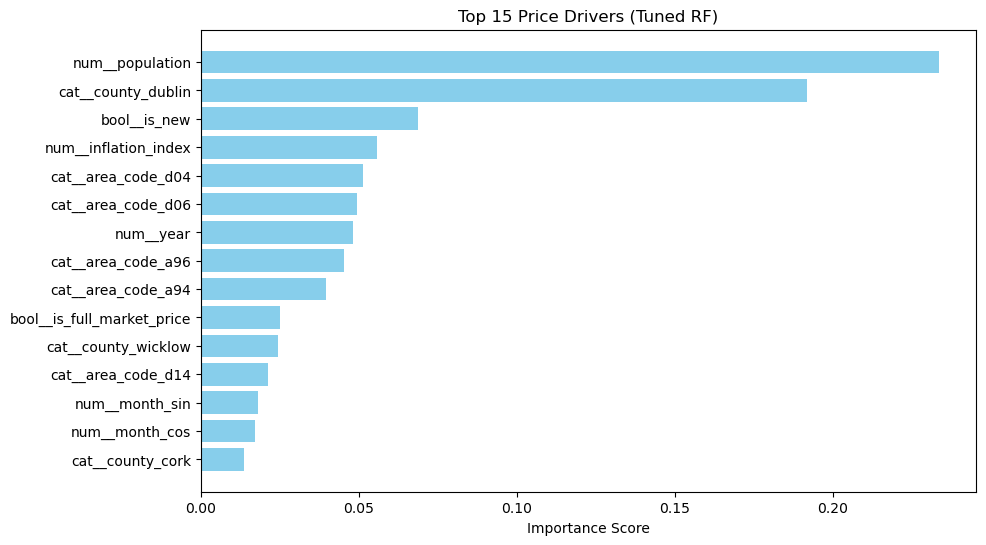

In [311]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importances = tuned_rf.feature_importances_


rf_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print("=== Top 15 Features for your Tuned Random Forest ===")
print(rf_feat_df.head(15))

plt.figure(figsize=(10, 6))
plt.barh(rf_feat_df['Feature'].head(15), rf_feat_df['Importance'].head(15), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Price Drivers (Tuned RF)')
plt.gca().invert_yaxis()
plt.show()

**Fine tuning Ridge model**

In [312]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import numpy as np

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
}


ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train, y_train)

best_alpha = ridge_search.best_params_['regressor__alpha']
best_cv_r2 = ridge_search.best_score_

y_test_pred = ridge_search.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n--- Ridge Tuning Results ---")
print(f"Best Alpha: {best_alpha}")
print(f"Best CV R²: {best_cv_r2:.4f}")
print(f"Final Test R²: {test_r2:.4f}")
print(f"Final Test MAE: {test_mae:.2f}")
print(f"Final Test RMSE: {test_rmse:.2f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

--- Ridge Tuning Results ---
Best Alpha: 0.01
Best CV R²: 0.4712
Final Test R²: 0.4204
Final Test MAE: 120419.42
Final Test RMSE: 179960.32


The best alpha value for Ridge is: 0.01

Looking at the highest absolute coefficients 

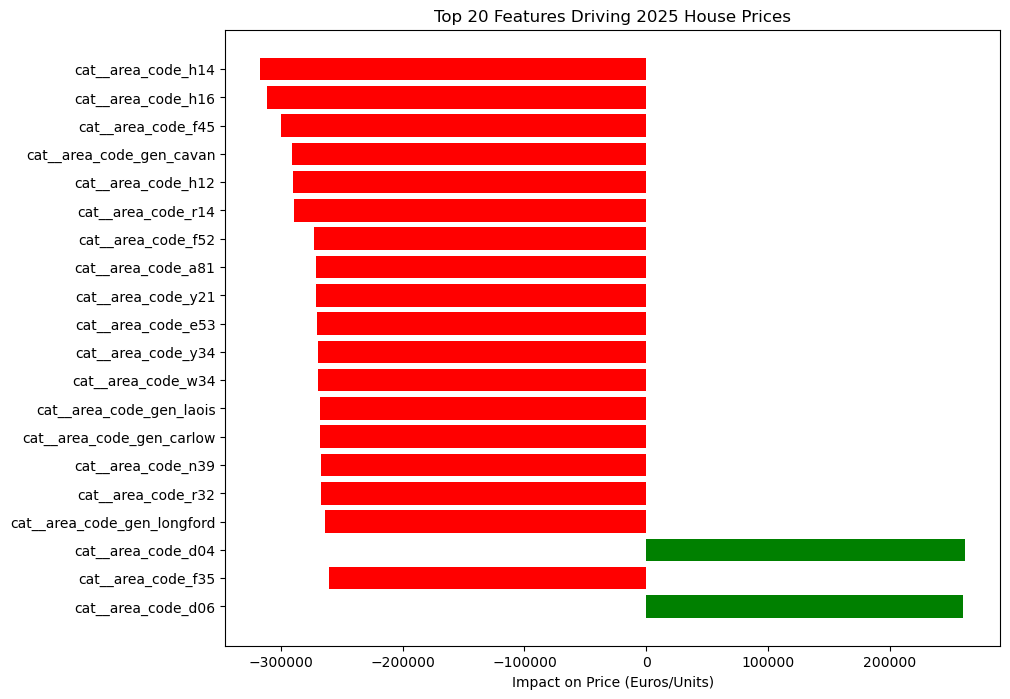

In [313]:
ohe_feature_names = ridge_search.best_estimator_.named_steps['preprocessor']\
    .get_feature_names_out()

coefficients = ridge_search.best_estimator_.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': ohe_feature_names,
    'Coefficient': coefficients
})

coef_df['Abs_Impact'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

plt.figure(figsize=(10, 8))
top_20 = coef_df.head(20)
plt.barh(top_20['Feature'], top_20['Coefficient'], color=['green' if x > 0 else 'red' for x in top_20['Coefficient']])
plt.xlabel('Impact on Price (Euros/Units)')
plt.title('Top 20 Features Driving 2025 House Prices')
plt.gca().invert_yaxis()
plt.show()

Comparison of Algorithms and Results

Our model used linear regression, ridge regression, and random forest algorithms to predict prices. The evaluation metrics we looked at were the mean absolute error (MAE), root mean squared error (RMSE), and coefficient of determination (R²).

Both linear models achieved moderate performance, explaining the variance in price with minimal overfitting.

The random forest model achieved higher R² performance, but worse on the test set and cross-validation. Tuning improved it somewhat but not enough to compete with the linear models. 

The results suggest that simpler models work better for this particular dataset. To improve performance more, we would want to incorporate more features to use with the model.

Proposed Ideas to Improve the Model

After using the standard algorithms to predict prices, we tried a couple of solutions to try and improve prediction which proved ineffective. 

The first was to use log_price instead of price, and unfortunately that only made performance worse. We also tried to change the IQR multiplier, but it did not help and also made the results worse. We tuned the random forest algorithm, which helped it slightly, but not enough to beat our linear models.

Finally, we tried engineering a new feature by squaring the year, i.e., df['year_squared'] = df['year'] ** 2. This was supposed to help the model capture nonlinear trends, however it did not seem to help because price is a linear feature, increasing steadily with each successive year.

